# Evaluasi Kinerja Digital Twin Edge–Cloud Multiskala

**Judul proyek:** *Evaluasi Kinerja Digital Twin Edge–Cloud Multiskala
untuk Monitoring Energi dan Okupansi*

Notebook ini menjalankan kembali eksperimen dari sumber data hingga
bukti integrasi. Seluruh fungsi inti diimpor dari `src/`; notebook tidak
menyalin atau membuat versi metode yang berbeda.

> **Batas unit analisis:** file CSV berisi **2.027.520 baris workload**
> yang dipindai seluruhnya untuk audit provenance dan kualitas. Hanya
> **5.000 baris terpilih merata** yang dipakai untuk benchmark jalur
> pemantauan. Volume replay bukan jumlah observasi lapangan independen,
> bukan data latih model, dan bukan bukti akurasi prediksi.

In [1]:
from __future__ import annotations

import hashlib
import json
import os
import platform
import re
import subprocess
import sys
import threading
import time
from datetime import datetime, timezone
from importlib.metadata import PackageNotFoundError, version
from pathlib import Path
from urllib.error import HTTPError
from urllib.request import urlopen

import numpy as np
import pandas as pd
from IPython.display import Image, Markdown, display
from jsonschema import Draft202012Validator, FormatChecker

# Notebook dapat dijalankan dari root repositori atau folder notebooks/.
ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
if not (ROOT / "src").is_dir():
    raise RuntimeError(
        "Jalankan notebook dari root repositori atau folder notebooks/."
    )
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

NOTEBOOK_OUTPUT = ROOT / "outputs" / "notebook"
FIGURES = NOTEBOOK_OUTPUT / "figures"
MPL_CACHE = NOTEBOOK_OUTPUT / ".matplotlib"
for directory in (NOTEBOOK_OUTPUT, FIGURES, MPL_CACHE):
    directory.mkdir(parents=True, exist_ok=True)
os.environ.setdefault("MPLCONFIGDIR", str(MPL_CACHE))

from src.benchmark.edge_cloud_benchmark import (
    benchmark,
    build_monitoring_record,
)
from src.data.audit_trace import audit_trace, load_trace
from src.data.prepare_historical_replay import prepare_historical_replay
from src.replay.replay_server import ReplayState, make_handler
from src.reporting.generate_figures import (
    plot_latency,
    plot_multiscale_contract,
    plot_monitoring_checks,
    plot_replay_provenance,
    plot_trace_profile,
)
from http.server import ThreadingHTTPServer

pd.set_option("display.max_columns", 30)
pd.set_option("display.max_colwidth", 120)
pd.set_option("display.float_format", lambda value: f"{value:,.6f}")


def write_json(path: Path, value: object) -> None:
    path.write_text(
        json.dumps(value, indent=2, ensure_ascii=False, default=str),
        encoding="utf-8",
    )


def sha256_file(path: Path) -> str:
    digest = hashlib.sha256()
    with path.open("rb") as handle:
        for chunk in iter(lambda: handle.read(1024 * 1024), b""):
            digest.update(chunk)
    return digest.hexdigest()


def package_version(name: str) -> str:
    try:
        return version(name)
    except PackageNotFoundError:
        return "tidak terdeteksi"


print(f"Root repositori : {ROOT}")
print(f"Output notebook  : {NOTEBOOK_OUTPUT}")
print(f"Python           : {sys.version.split()[0]}")

Root repositori : /Users/macbookpro/Documents/jurnal_penelitian
Output notebook  : /Users/macbookpro/Documents/jurnal_penelitian/outputs/notebook
Python           : 3.11.9


## 1. Desain evaluasi dan batas klaim

Evaluasi ini menjawab lima pertanyaan operasional:

1. Apakah sumber historis dan workload replay dapat ditelusuri secara
   eksplisit?
2. Apakah jalur lokal dapat memeriksa, merutekan, dan menserialisasi
   payload dalam deadline konfigurasi 3,5 detik?
3. Bagaimana kinerja edge–cloud selektif dibandingkan baseline
   cloud-only pada profil jaringan terkonfigurasi yang sama?
4. Apakah energi turunan, okupansi, provenance, dan konteks tiga skala
   memenuhi kontrak JSON yang sama dengan API dan dashboard?
5. Bagian mana dari judul yang sudah didukung bukti dan bagian mana yang
   masih memerlukan validasi perangkat, jaringan, atau pengguna nyata?

Tidak ada pelatihan model, target prediksi, pembagian train/test, maupun
metrik akurasi. Workbook XLSX adalah telemetry arsip dari arsitektur
ESP32–Raspberry Pi. `DeviceID` pada workbook adalah label gateway
Raspberry Pi yang mengagregasi telemetry, bukan ID node sumber per
baris atau bukti hanya ada satu perangkat fisik;
firmware lama menghitung `power_legacy_w` sebagai V×I dan
`power_formula_w` hanya memeriksa konsistensi. Energi XLSX asli dan
energi payload replay dihitung terpisah. Peneliti melaporkan
perbandingan perangkat dengan meter kWh PLN, tetapi rekaman interval
pembanding tidak tersedia untuk menghitung galat secara reproduktif.

In [2]:
CONFIG_PATH = ROOT / "configs" / "experiment.json"
SCHEMA_PATH = ROOT / "schemas" / "telemetry.schema.json"
config = json.loads(CONFIG_PATH.read_text(encoding="utf-8"))

reference_path = ROOT / config["data"]["reference_trace"]
replay_path = ROOT / config["data"]["historical_replay"]
expected_rows = int(config["replay"]["expected_rows"])
reference_rows = int(config["replay"]["reference_rows_per_replay"])
benchmark_rows = int(config["replay"]["benchmark_sample_size"])

required_paths = {
    "Konfigurasi": CONFIG_PATH,
    "Skema telemetry": SCHEMA_PATH,
    "Workbook historis asli": reference_path,
    "CSV workload replay": replay_path,
}
path_table = pd.DataFrame(
    [
        {
            "Artefak": label,
            "Path": str(path.relative_to(ROOT)),
            "Ada": path.exists(),
            "Ukuran (MiB)": path.stat().st_size / 1024**2 if path.exists() else None,
        }
        for label, path in required_paths.items()
    ]
)
display(path_table)
assert path_table["Ada"].all(), "Ada artefak input wajib yang tidak ditemukan."

scope_table = pd.DataFrame(
    [
        ["Baris workbook historis yang diharapkan", f"{reference_rows:,}"],
        ["Baris CSV yang wajib dipindai", f"{expected_rows:,}"],
        ["Baris untuk benchmark", f"{benchmark_rows:,}"],
        ["Rasio benchmark terhadap workload", f"{benchmark_rows / expected_rows:.4%}"],
        [
            "Deadline operasional terkonfigurasi",
            f"{config['data']['near_realtime_deadline_seconds']} detik",
        ],
        ["Dasar deadline", config["data"]["deadline_basis"]],
        ["Seed emulasi jaringan", config["replay"]["random_seed"]],
    ],
    columns=["Parameter", "Nilai"],
)
display(scope_table)

,Artefak,Path,Ada,Ukuran (MiB)
0,Konfigurasi,configs/experiment.json,True,0.004988
1,Skema telemetry,schemas/telemetry.schema.json,True,0.007189
2,Workbook historis asli,Data/sensor_data_export_2026-05-17_to_2026-05-23.xlsx,True,3.652272
3,CSV workload replay,Data/sensor_data.csv,True,154.735272


,Parameter,Nilai
0,Baris workbook historis yang diharapkan,"92,160"
1,Baris CSV yang wajib dipindai,"2,027,520"
2,Baris untuk benchmark,"5,000"
3,Rasio benchmark terhadap workload,0.2466%
4,Deadline operasional terkonfigurasi,3.5 detik
5,Dasar deadline,operational deadline rounded from the original trace median inter-record gap of 3.5251918 seconds; not the legacy fi...
6,Seed emulasi jaringan,20260728


## 2. Audit trace historis asli

Fungsi `audit_trace()` membaca workbook asli, menormalkan nama kolom,
memeriksa timestamp, nilai hilang/nol, statistik variabel, korelasi, dan
SHA-256. Hash mengikat hasil pada file sumber yang benar.

In [3]:
trace_started = time.perf_counter()
trace_audit = audit_trace(
    reference_path,
    max_energy_gap_seconds=float(
        config["energy_integration"]["max_gap_seconds"]
    ),
)
trace_seconds = time.perf_counter() - trace_started
write_json(NOTEBOOK_OUTPUT / "trace_audit.json", trace_audit)

source = trace_audit["source"]
sampling = trace_audit["sampling"]
field_energy = trace_audit["derived_energy"]
trace_summary = pd.DataFrame(
    [
        ["Jumlah observasi", f"{source['rows']:,}"],
        ["Jumlah ID gateway", source["device_count"]],
        ["ID gateway", ", ".join(source["device_ids"])],
        ["Peran ESP32", config["project"]["field_sensor_trace"]["hardware_roles"]["ESP32"]],
        ["Peran Raspberry Pi", config["project"]["field_sensor_trace"]["hardware_roles"]["Raspberry Pi"]],
        ["Rentang awal UTC", source["timestamp_start_utc"]],
        ["Rentang akhir UTC", source["timestamp_end_utc"]],
        ["Timestamp duplikat", f"{source['duplicate_timestamps']:,}"],
        ["Interval median", f"{sampling['gap_seconds_p50']:.3f} detik"],
        ["Interval P95", f"{sampling['gap_seconds_p95']:.3f} detik"],
        [
            "Energi XLSX sensor lapangan",
            f"{field_energy['energy_wh']:.3f} Wh",
        ],
        ["SHA-256", source["sha256"]],
        ["Durasi audit", f"{trace_seconds:.2f} detik"],
    ],
    columns=["Pemeriksaan", "Hasil"],
)
display(trace_summary.style.hide(axis="index"))
assert source["rows"] == reference_rows
assert source["device_count"] >= 1

Pemeriksaan,Hasil
Jumlah observasi,"92,160"
Jumlah ID gateway,1
ID gateway,RASPBERRY_PI_GATEWAY_001
Peran ESP32,"node akuisisi lapangan untuk suhu, kelembapan, tegangan RMS, arus RMS, dan daya legacy V×I"
Peran Raspberry Pi,gateway agregasi edge; pipeline legacy mencatat ID gateway ini untuk telemetry gabungan dan membawa jalur kamera/okupansi secara terpisah
Rentang awal UTC,2026-05-19T17:10:55.418478500+00:00
Rentang akhir UTC,2026-05-23T18:22:06.727676100+00:00
Timestamp duplikat,0
Interval median,3.525 detik
Interval P95,5.102 detik


In [4]:
variable_table = (
    pd.DataFrame(trace_audit["variables"])
    .T.reset_index(names="Variabel")
)
display(
    variable_table[
        ["Variabel", "count", "missing", "zero_rate", "mean", "std", "p50", "p95", "p99", "max"]
    ].style.format(
        {
            "count": "{:,.0f}",
            "missing": "{:,.0f}",
            "zero_rate": "{:.2%}",
            "mean": "{:,.3f}",
            "std": "{:,.3f}",
            "p50": "{:,.3f}",
            "p95": "{:,.3f}",
            "p99": "{:,.3f}",
            "max": "{:,.3f}",
        },
        na_rep="—",
    ).hide(axis="index")
)

correlation = pd.DataFrame(trace_audit["pearson_correlation"])
display(Markdown("**Korelasi Pearson (deskriptif, bukan kausal):**"))
display(correlation.style.background_gradient(cmap="RdBu", vmin=-1, vmax=1).format("{:.3f}"))

Variabel,count,missing,zero_rate,mean,std,p50,p95,p99,max
temperature_c,"92,160",0,0.00%,30.188,1.853,30.500,32.800,33.500,33.900
humidity_pct,"92,160",0,0.00%,66.625,8.459,69.000,76.000,79.000,82.000
voltage_v,"92,160",0,3.05%,220.100,39.706,227.100,238.500,242.500,250.900
current_a,"92,160",0,1.28%,0.160,0.022,0.160,0.180,0.190,2.200
power_w,"92,160",0,3.05%,35.672,6.982,36.500,41.100,42.600,484.000
people_count,"92,158",2,73.08%,0.877,1.486,0.000,3.000,5.000,5.000


**Korelasi Pearson (deskriptif, bukan kausal):**

,temperature_c,humidity_pct,voltage_v,current_a,power_w,people_count
temperature_c,1.000,0.567,-0.082,-0.114,-0.169,-0.008
humidity_pct,0.567,1.000,-0.071,-0.297,-0.187,0.085
voltage_v,-0.082,-0.071,1.000,0.421,0.935,0.153
current_a,-0.114,-0.297,0.421,1.000,0.565,0.124
power_w,-0.169,-0.187,0.935,0.565,1.000,0.195
people_count,-0.008,0.085,0.153,0.124,0.195,1.000


## 3. Audit penuh workload replay dan lineage

`prepare_historical_replay()` memindai seluruh CSV secara bertahap
(*chunked*), mengaudit jumlah baris dan kualitas, lalu mengambil 5.000
posisi merata. Jadi:

- **2.027.520 baris** dipakai untuk audit workload/provenance;
- **5.000 baris** dipakai untuk benchmark;
- tidak ada klaim bahwa 2.027.520 baris adalah observasi lapangan
  independen.

Audit lineage juga membandingkan payload antarblok dan blok pertama
terhadap workbook ekspor. Perbedaan yang ditemukan harus dilaporkan
sebagai transformasi/imputasi historis, bukan disamarkan sebagai salinan
mentah.

In [5]:
replay_started = time.perf_counter()
replay_sample, replay_audit = prepare_historical_replay(
    replay_path,
    expected_rows=expected_rows,
    reference_rows=reference_rows,
    sample_size=benchmark_rows,
    reference_trace=reference_path,
    max_energy_gap_seconds=float(
        config["energy_integration"]["max_gap_seconds"]
    ),
)
replay_seconds = time.perf_counter() - replay_started

replay_sample_path = NOTEBOOK_OUTPUT / "historical_replay_sample.csv"
replay_sample.to_csv(replay_sample_path, index=False)
write_json(NOTEBOOK_OUTPUT / "historical_replay_audit.json", replay_audit)
energy_audit = replay_audit["quality"]["energy_integration"]
occupancy_audit = replay_audit["quality"]["occupancy"]

replay_summary = pd.DataFrame(
    [
        ["Baris CSV dipindai", f"{replay_audit['source']['rows']:,}"],
        ["Ekspektasi baris cocok", replay_audit["source"]["expected_rows_match"]],
        ["Blok replay terinferensi", replay_audit["provenance"]["inferred_replay_blocks"]],
        ["Baris trace rujukan", f"{replay_audit['provenance']['reference_rows']:,}"],
        ["Sampel benchmark", f"{len(replay_sample):,}"],
        [
            "Blok tercakup sampel",
            f"{len(replay_audit['benchmark_sample']['covered_replay_blocks'])} blok",
        ],
        ["Durasi audit + sampling", f"{replay_seconds:.2f} detik"],
        [
            "Energi satu blok payload replay",
            f"{energy_audit['energy_wh']:.3f} Wh",
        ],
        [
            "Status okupansi sampel",
            f"{occupancy_audit['occupied_sample_count']:,} terisi / "
            f"{occupancy_audit['unoccupied_sample_count']:,} kosong",
        ],
    ],
    columns=["Pemeriksaan", "Hasil"],
)
display(replay_summary.style.hide(axis="index"))

assert replay_audit["source"]["rows"] == expected_rows
assert replay_audit["source"]["expected_rows_match"] is True
assert len(replay_sample) == benchmark_rows
assert replay_audit["research_role"]["independent_field_observations_claimed"] is False
assert replay_audit["research_role"]["model_training_used"] is False

Pemeriksaan,Hasil
Baris CSV dipindai,"2,027,520"
Ekspektasi baris cocok,True
Blok replay terinferensi,22.000000
Baris trace rujukan,"92,160"
Sampel benchmark,"5,000"
Blok tercakup sampel,22 blok
Durasi audit + sampling,25.71 detik
Energi satu blok payload replay,3474.371 Wh
Status okupansi sampel,"4,748 terisi / 252 kosong"


In [6]:
# Renderer ini memakai struktur lineage versi terbaru dan tetap memberi
# fallback informatif bila notebook dibuka bersama artefak versi lama.
lineage = replay_audit.get("lineage", {})
if not lineage:
    display(
        Markdown(
            "⚠️ Artefak ini belum memiliki `audit['lineage']`. "
            "Jalankan ulang dengan versi pipeline terbaru."
        )
    )
else:
    lineage_summary = pd.DataFrame(
        [
            ["Klasifikasi", lineage.get("classification", "—")],
            [
                "Payload semua blok identik dengan blok pertama",
                lineage.get("all_replay_payloads_identical_to_first_block", "—"),
            ],
            [
                "Kode transformasi historis tersedia",
                lineage.get("transformation_code_available", "—"),
            ],
            [
                "Kolom payload diperiksa",
                ", ".join(lineage.get("payload_columns_checked", [])),
            ],
            ["Interpretasi", lineage.get("interpretation", "—")],
        ],
        columns=["Aspek lineage", "Hasil"],
    )
    display(lineage_summary.style.hide(axis="index"))

    comparison = lineage.get("first_block_vs_exported_workbook", {})
    by_column = comparison.get("by_column", {})
    if by_column:
        lineage_columns = (
            pd.DataFrame.from_dict(by_column, orient="index")
            .reset_index(names="Variabel")
        )
        preferred = [
            column
            for column in [
                "Variabel",
                "rows_compared",
                "match_count",
                "changed_count",
                "match_rate",
            ]
            if column in lineage_columns.columns
        ]
        display(
            lineage_columns[preferred].style.format(
                {
                    "rows_compared": "{:,.0f}",
                    "match_count": "{:,.0f}",
                    "changed_count": "{:,.0f}",
                    "match_rate": "{:.3%}",
                },
                na_rep="—",
            ).hide(axis="index")
        )

    cross_block = lineage.get("cross_block_mismatch_counts", {})
    if cross_block:
        display(
            pd.DataFrame(
                [
                    {"Variabel": key, "Ketidakcocokan antarblok": value}
                    for key, value in cross_block.items()
                ]
            ).style.format(
                {"Ketidakcocokan antarblok": "{:,.0f}"}
            ).hide(axis="index")
        )

Aspek lineage,Hasil
Klasifikasi,deterministic_replay_of_transformed_historical_trace
Payload semua blok identik dengan blok pertama,True
Kode transformasi historis tersedia,False
Kolom payload diperiksa,"DeviceID, Suhu (C), Kelembaban (%), Tegangan (V), Arus (A), Daya (W), Jumlah Orang"
Interpretasi,"The full CSV is suitable as a deterministic replay workload. It must not be described as new measurements, independent samples, augmentation diversity, or a raw copy of the XLSX."


Variabel,rows_compared,match_count,changed_count,match_rate
device_id,"92,160","92,160",0,100.000%
temperature_c,"92,160","92,158",2,99.998%
humidity_pct,"92,160","92,158",2,99.998%
voltage_v,"92,160","89,349","2,811",96.950%
current_a,"92,160","90,982","1,178",98.722%
power_w,"92,160","89,348","2,812",96.949%
people_count,"92,160","12,880","79,280",13.976%


Variabel,Ketidakcocokan antarblok
DeviceID,0
Suhu (C),0
Kelembaban (%),0
Tegangan (V),0
Arus (A),0
Daya (W),0
Jumlah Orang,0


## 4. Benchmark jalur pemantauan edge–cloud

Benchmark mengukur waktu lokal aktual pada mesin yang menjalankan
notebook untuk validasi/routing/pembuatan payload dan serialisasi JSON.
Latensi jaringan cloud berasal dari profil konfigurasi dengan seed
tetap; nilainya bukan pengukuran public cloud atau jaringan lapangan.

In [7]:
workload_scope = {
    "source_type": "historical_replay",
    "available_rows_scanned": replay_audit["source"]["rows"],
    "messages_benchmarked": len(replay_sample),
    "available_rows_are_not_messages_benchmarked": True,
    "independent_reference_rows": replay_audit["provenance"]["reference_rows"],
    "sample_selection": replay_audit["benchmark_sample"]["method"],
    "covered_replay_blocks": replay_audit["benchmark_sample"]["covered_replay_blocks"],
    "lineage_classification": replay_audit.get("lineage", {}).get(
        "classification",
        replay_audit["provenance"].get("lineage_classification", "belum diaudit"),
    ),
    "role": (
        "energy-occupancy monitoring and multiscale Digital Twin "
        "historical replay"
    ),
    "used_for_model_training_or_accuracy": False,
}

benchmark_started = time.perf_counter()
benchmark_report = benchmark(replay_sample, config, workload_scope)
benchmark_seconds = time.perf_counter() - benchmark_started
write_json(NOTEBOOK_OUTPUT / "benchmark_metrics.json", benchmark_report)

local = benchmark_report["actual_local_monitoring"]
serialization = benchmark_report["actual_json_serialization"]
edge = benchmark_report["actual_edge_path"]
cloud = benchmark_report["configured_cloud_route_end_to_end"]
mixed = benchmark_report["configured_end_to_end"]
cloud_only = benchmark_report["configured_cloud_only_baseline"]
architecture_comparison = benchmark_report["architecture_comparison"]
benchmark_scope = benchmark_report["scope"]

scope_contract_table = pd.DataFrame(
    [
        [
            "Baris workload dipindai",
            benchmark_scope["workload"]["available_rows_scanned"],
        ],
        [
            "Pesan dibenchmark",
            benchmark_scope["messages_benchmarked"],
        ],
        [
            "Baris tersedia bukan jumlah pesan benchmark",
            benchmark_scope[
                "available_rows_are_not_messages_benchmarked"
            ],
        ],
    ],
    columns=["Kontrak scope benchmark", "Nilai"],
)
display(scope_contract_table.style.hide(axis="index"))
assert (
    benchmark_scope["workload"]["available_rows_scanned"]
    == expected_rows
)
assert benchmark_scope["messages_benchmarked"] == benchmark_rows
assert (
    benchmark_scope[
        "available_rows_are_not_messages_benchmarked"
    ]
    is True
)
assert (
    benchmark_scope["workload"][
        "available_rows_are_not_messages_benchmarked"
    ]
    is True
)

latency_table = pd.DataFrame(
    [
        ["Pemantauan lokal (terukur)", local["p50_ms"], local["p95_ms"], local["p99_ms"], local["max_ms"]],
        ["Serialisasi JSON (terukur)", serialization["p50_ms"], serialization["p95_ms"], serialization["p99_ms"], serialization["max_ms"]],
        ["Jalur edge lokal (terukur)", edge["p50_ms"], edge["p95_ms"], edge["p99_ms"], edge["max_ms"]],
        ["Rute cloud (jaringan terkonfigurasi)", cloud["p50_ms"], cloud["p95_ms"], cloud["p99_ms"], cloud["max_ms"]],
        ["Campuran semua rute", mixed["p50_ms"], mixed["p95_ms"], mixed["p99_ms"], mixed["max_ms"]],
        ["Baseline cloud-only", cloud_only["p50_ms"], cloud_only["p95_ms"], cloud_only["p99_ms"], cloud_only["max_ms"]],
    ],
    columns=["Komponen", "P50 (ms)", "P95 (ms)", "P99 (ms)", "Maks (ms)"],
)
display(
    latency_table.style.format(
        {column: "{:,.6f}" for column in latency_table.columns[1:]},
        na_rep="—",
    ).hide(axis="index")
)
print(f"Durasi loop benchmark: {benchmark_seconds:.2f} detik")
display(
    pd.DataFrame(
        [
            [
                "Reduksi P95 terkonfigurasi",
                architecture_comparison[
                    "configured_p95_latency_reduction_percent"
                ],
                "%",
            ],
            [
                "Offload pesan dari jaringan",
                architecture_comparison["network_offload_rate"] * 100,
                "%",
            ],
            [
                "Payload jaringan dihindari",
                architecture_comparison[
                    "network_payload_bytes_avoided"
                ],
                "byte",
            ],
        ],
        columns=["Pembanding arsitektur", "Nilai", "Satuan"],
    ).style.format({"Nilai": "{:,.3f}"}).hide(axis="index")
)

Kontrak scope benchmark,Nilai
Baris workload dipindai,2027520
Pesan dibenchmark,5000
Baris tersedia bukan jumlah pesan benchmark,True


Komponen,P50 (ms),P95 (ms),P99 (ms),Maks (ms)
Pemantauan lokal (terukur),0.045982,0.124885,0.250724,56.672877
Serialisasi JSON (terukur),0.029958,0.094405,0.210703,45.388253
Jalur edge lokal (terukur),0.076485,0.219366,0.439308,57.234856
Rute cloud (jaringan terkonfigurasi),43.508618,68.000890,72.748707,73.978635
Campuran semua rute,0.076740,0.286243,47.512945,73.978635
Baseline cloud-only,45.490393,64.751168,72.588958,108.960900


Durasi loop benchmark: 1.12 detik


Pembanding arsitektur,Nilai,Satuan
Reduksi P95 terkonfigurasi,99.558,%
Offload pesan dari jaringan,97.720,%
Payload jaringan dihindari,"10,672,142.000",byte


In [8]:
routing = benchmark_report["routing"]
quality = benchmark_report["data_quality"]
throughput = benchmark_report["throughput"]["sequential_messages_per_second"]
payload = benchmark_report["payload"]

routing_table = pd.DataFrame(
    [
        ["Edge", routing["edge_count"], routing["edge_count"] / len(replay_sample)],
        ["Cloud", routing["cloud_count"], routing["cloud_count"] / len(replay_sample)],
    ],
    columns=["Rute", "Jumlah pesan", "Proporsi"],
)
display(
    routing_table.style.format(
        {"Jumlah pesan": "{:,.0f}", "Proporsi": "{:.2%}"}
    ).hide(axis="index")
)

reason_table = pd.DataFrame(
    [
        {
            "Alasan routing": reason,
            "Jumlah": count,
            "Proporsi": count / len(replay_sample),
            "Tercakup sampel": count > 0,
        }
        for reason, count in routing["reason_counts"].items()
    ]
).sort_values("Jumlah", ascending=False)
display(
    reason_table.style.format(
        {"Jumlah": "{:,.0f}", "Proporsi": "{:.2%}"}
    ).hide(axis="index")
)

operational_table = pd.DataFrame(
    [
        ["Payload valid", f"{quality['valid_count']:,}"],
        ["Payload invalid", f"{quality['invalid_count']:,}"],
        ["Throughput loop sekuensial", f"{throughput:,.1f} pesan/detik"],
        ["Ukuran payload rata-rata", f"{payload['mean_bytes']:,.1f} byte"],
        ["Ukuran payload P95", f"{payload['p95_bytes']:,.1f} byte"],
        ["Pesan dicoba", f"{mixed['attempted_count']:,}"],
        ["Pesan terkirim", f"{mixed['delivered_count']:,}"],
        ["Pesan drop", f"{mixed['dropped_count']:,}"],
        [
            "Deadline miss di antara pesan terkirim",
            f"{mixed['deadline_miss_count']:,}/{mixed['delivered_count']:,}",
        ],
    ],
    columns=["Metrik", "Hasil"],
)
display(operational_table.style.hide(axis="index"))
assert sum(routing["reason_counts"].values()) == len(replay_sample)
assert set(routing["covered_reasons"]).isdisjoint(
    routing["uncovered_reasons"]
)
assert (
    mixed["delivered_count"] + mixed["dropped_count"]
    == mixed["attempted_count"]
    == len(replay_sample)
)

Rute,Jumlah pesan,Proporsi
Edge,"4,886",97.72%
Cloud,114,2.28%


Alasan routing,Jumlah,Proporsi,Tercakup sampel
normal_local_monitoring,"4,886",97.72%,True
power_above_trace_p99,114,2.28%,True
missing_or_nonfinite_value,0,0.00%,False
invalid_electrical_reading,0,0.00%,False
current_below_legacy_threshold,0,0.00%,False


Metrik,Hasil
Payload valid,"5,000"
Payload invalid,0
Throughput loop sekuensial,"4,544.2 pesan/detik"
Ukuran payload rata-rata,"2,184.3 byte"
Ukuran payload P95,"2,190.0 byte"
Pesan dicoba,"5,000"
Pesan terkirim,"5,000"
Pesan drop,0
Deadline miss di antara pesan terkirim,"0/5,000"


In [9]:
deadline_ms = (
    float(config["data"]["near_realtime_deadline_seconds"]) * 1000
)
p95_headroom_ms = deadline_ms - float(mixed["p95_ms"])
p99_headroom_ms = deadline_ms - float(mixed["p99_ms"])
near_realtime_table = pd.DataFrame(
    [
        ["Deadline operasional terkonfigurasi", deadline_ms],
        ["P95 campuran", mixed["p95_ms"]],
        ["Headroom P95", p95_headroom_ms],
        ["P99 campuran", mixed["p99_ms"]],
        ["Headroom P99", p99_headroom_ms],
        ["Tingkat deadline miss", mixed["deadline_miss_rate"]],
        ["Pesan dicoba", mixed["attempted_count"]],
        ["Pesan terkirim", mixed["delivered_count"]],
        ["Pesan drop", mixed["dropped_count"]],
    ],
    columns=["Pemeriksaan near real-time", "Nilai"],
)
display(
    near_realtime_table.style.format(
        {"Nilai": "{:,.6f}"}
    ).hide(axis="index")
)

assert mixed["deadline_miss_count"] == 0
display(
    Markdown(
        f"Pada **skenario uji ini**, P95 campuran menyisakan "
        f"**{p95_headroom_ms:,.3f} ms** dari deadline "
        f"**{deadline_ms:,.0f} ms**. Kesimpulan ini hanya mencakup "
        f"pemrosesan lokal dan {mixed['delivered_count']:,} pesan yang "
        f"terkirim pada emulasi jaringan ({mixed['dropped_count']:,} "
        "drop); "
        "render browser, broker produksi, perangkat edge nyata, dan "
        "public cloud belum diukur."
    )
)

Pemeriksaan near real-time,Nilai
Deadline operasional terkonfigurasi,"3,500.000000"
P95 campuran,0.286243
Headroom P95,"3,499.713757"
P99 campuran,47.512945
Headroom P99,"3,452.487055"
Tingkat deadline miss,0.000000
Pesan dicoba,"5,000.000000"
Pesan terkirim,"5,000.000000"
Pesan drop,0.000000


Pada **skenario uji ini**, P95 campuran menyisakan **3,499.714 ms** dari deadline **3,500 ms**. Kesimpulan ini hanya mencakup pemrosesan lokal dan 5,000 pesan yang terkirim pada emulasi jaringan (0 drop); render browser, broker produksi, perangkat edge nyata, dan public cloud belum diukur.

## 5. Validasi kontrak JSON untuk seluruh 5.000 payload benchmark

Setiap baris sampel dibentuk kembali dengan
`build_monitoring_record()`—fungsi yang juga digunakan benchmark dan
replay API—kemudian divalidasi terhadap JSON Schema Draft 2020-12.
Pemeriksaan format tanggal-waktu diaktifkan dan serialisasi ketat
menolak `NaN`/`Infinity`.

In [10]:
schema = json.loads(SCHEMA_PATH.read_text(encoding="utf-8"))
validator = Draft202012Validator(
    schema,
    format_checker=FormatChecker(),
)
threshold = float(
    config["benchmark"]["cloud_routing"]["power_anomaly_threshold_w"]
)
schema_errors = []
example_payload = None
validation_started = time.perf_counter()

for row_number, (_, row) in enumerate(replay_sample.iterrows()):
    record, _ = build_monitoring_record(row, threshold)
    row_errors = sorted(
        validator.iter_errors(record),
        key=lambda error: list(error.absolute_path),
    )
    if row_errors:
        schema_errors.extend(
            {
                "row": row_number,
                "path": ".".join(map(str, error.absolute_path)) or "$",
                "message": error.message,
            }
            for error in row_errors
        )
    # allow_nan=False adalah pemeriksaan kedua terhadap angka non-finite.
    json.dumps(record, allow_nan=False)
    if example_payload is None:
        example_payload = record

validation_seconds = time.perf_counter() - validation_started
schema_validation = {
    "schema": str(SCHEMA_PATH.relative_to(ROOT)),
    "draft": schema["$schema"],
    "payloads_checked": len(replay_sample),
    "valid_payloads": len(replay_sample) - len({error["row"] for error in schema_errors}),
    "invalid_payloads": len({error["row"] for error in schema_errors}),
    "error_count": len(schema_errors),
    "format_checker_enabled": True,
    "strict_json_serialization": True,
    "duration_seconds": validation_seconds,
    "first_errors": schema_errors[:20],
}
write_json(NOTEBOOK_OUTPUT / "schema_validation.json", schema_validation)
display(pd.DataFrame([schema_validation]).drop(columns=["first_errors"]))
assert not schema_errors, schema_errors[:3]

display(Markdown("**Contoh payload yang lolos validasi:**"))
print(json.dumps(example_payload, indent=2, ensure_ascii=False))

,schema,draft,payloads_checked,valid_payloads,invalid_payloads,error_count,format_checker_enabled,strict_json_serialization,duration_seconds
0,schemas/telemetry.schema.json,https://json-schema.org/draft/2020-12/schema,5000,5000,0,0,True,True,4.173682


**Contoh payload yang lolos validasi:**

{
  "timestamp_utc": "2026-02-23T23:14:43.896301+00:00",
  "device_id": "RASPBERRY_PI_GATEWAY_001",
  "source_type": "historical_replay",
  "provenance": {
    "lineage_classification": "deterministic_replay_of_transformed_historical_trace",
    "source_timestamp_utc": "2026-05-19T17:10:55.418478500+00:00",
    "replay_timestamp_utc": "2026-02-23T23:14:43.896301+00:00",
    "replay_id": "historical_replay_00",
    "replay_block_id": 0,
    "source_row_id": "historical:000000",
    "source_row_index": 0
  },
  "monitoring": {
    "temperature_c": 27.5,
    "humidity_pct": 65.0,
    "voltage_v": 220.0,
    "current_a": 2.2,
    "power_legacy_w": 484.0,
    "power_formula_w": 484.0,
    "power_consistency_error_w": 0.0,
    "energy_interval_legacy_wh": 0.0,
    "energy_cumulative_legacy_wh": 0.0,
    "energy_integration_status": "trace_start",
    "people_count": 5,
    "occupancy_status": "occupied",
    "voltage_status": "normal",
    "current_status": "normal"
  },
  "digital_twin": {


## 6. Smoke test replay API secara *in-process*

Server HTTP dijalankan sementara pada alamat loopback dan port acak.
Uji berikut mengakses endpoint yang sama dengan dashboard, memeriksa
status HTTP, struktur envelope, dan kembali memvalidasi payload
`/latest` serta `/history` terhadap schema. Dua permintaan `/latest`
membuktikan jam replay bersifat *request-driven*: setiap permintaan
memajukan tepat satu baris, sedangkan `/history` hanya mengembalikan
baris yang benar-benar sudah dilayani. Server selalu dihentikan pada
blok `finally`.

In [11]:
def get_json(url: str) -> tuple[int, dict]:
    try:
        with urlopen(url, timeout=5) as response:
            return response.status, json.loads(response.read().decode("utf-8"))
    except HTTPError as error:
        return error.code, json.loads(error.read().decode("utf-8"))


state = ReplayState(replay_sample_path, config, input_format="canonical")
server = ThreadingHTTPServer(("127.0.0.1", 0), make_handler(state))
server_thread = threading.Thread(target=server.serve_forever, daemon=True)
server_thread.start()
api_base = f"http://127.0.0.1:{server.server_address[1]}"

api_results = []
response_payloads = {}
try:
    for label, endpoint, expected_status in [
        ("health", "/api/health", 200),
        ("latest pertama", "/api/telemetry/latest", 200),
        ("latest kedua", "/api/telemetry/latest", 200),
        ("history", "/api/telemetry/history?limit=3", 200),
        ("invalid limit", "/api/telemetry/history?limit=abc", 400),
        ("not found", "/api/tidak-ada", 404),
    ]:
        status, payload = get_json(api_base + endpoint)
        response_payloads[label] = payload
        api_results.append(
            {
                "Uji": label,
                "Endpoint": endpoint,
                "Status": status,
                "Ekspektasi": expected_status,
                "Lulus": status == expected_status,
            }
        )
finally:
    server.shutdown()
    server.server_close()
    server_thread.join(timeout=5)

api_table = pd.DataFrame(api_results)
display(api_table.style.hide(axis="index"))
assert api_table["Lulus"].all()
health = response_payloads["health"]
latest_first = response_payloads["latest pertama"]["data"]
latest_second = response_payloads["latest kedua"]["data"]
history_payloads = response_payloads["history"]["data"]
expected_lineage = replay_audit["lineage"]["classification"]

assert health["mode"] == "monitoring_without_power_estimation_model"
assert health["replay_clock"] == "request_driven_one_row_per_latest_call"
assert health["lineage_classification"] == expected_lineage
assert health["rows_loaded"] == len(replay_sample)
assert response_payloads["latest pertama"]["success"] is True
assert response_payloads["latest kedua"]["success"] is True
assert len(history_payloads) == 2
assert [
    latest_first["provenance"]["source_row_id"],
    latest_second["provenance"]["source_row_id"],
] == [
    record["provenance"]["source_row_id"]
    for record in history_payloads
]
assert history_payloads == [latest_first, latest_second]
assert [
    latest_first["provenance"]["source_row_index"],
    latest_second["provenance"]["source_row_index"],
] == replay_sample.iloc[:2]["source_row_index"].astype(int).tolist()

api_schema_payloads = [
    latest_first,
    latest_second,
    *history_payloads,
]
for payload in api_schema_payloads:
    validator.validate(payload)
    assert (
        payload["provenance"]["lineage_classification"]
        == expected_lineage
    )

api_smoke = {
    "mode": "in_process_loopback_http",
    "tests": api_results,
    "all_passed": bool(api_table["Lulus"].all()),
    "schema_valid_payload_count": len(api_schema_payloads),
    "request_driven_history_count": len(history_payloads),
    "served_source_row_ids": [
        payload["provenance"]["source_row_id"]
        for payload in history_payloads
    ],
    "health": health,
}
write_json(NOTEBOOK_OUTPUT / "api_smoke_test.json", api_smoke)

Uji,Endpoint,Status,Ekspektasi,Lulus
health,/api/health,200,200,True
latest pertama,/api/telemetry/latest,200,200,True
latest kedua,/api/telemetry/latest,200,200,True
history,/api/telemetry/history?limit=3,200,200,True
invalid limit,/api/telemetry/history?limit=abc,400,400,True
not found,/api/tidak-ada,404,404,True


## 7. Visual hasil evaluasi

Kelima gambar dibuat ulang dari data dan laporan pada run notebook ini,
lalu disimpan hanya di `outputs/notebook/figures/`. Notebook tidak
menimpa gambar final proposal.

In [12]:
real_trace = load_trace(reference_path)
figure_paths = {
    "Profil trace": FIGURES / "01_trace_profile.png",
    "Provenance replay": FIGURES / "02_replay_provenance.png",
    "Pemeriksaan monitoring": FIGURES / "03_monitoring_checks.png",
    "Karakteristik latensi": FIGURES / "04_latency_characteristics.png",
    "Digital Twin multiskala": FIGURES / "05_multiscale_digital_twin.png",
}

plot_trace_profile(real_trace, figure_paths["Profil trace"])
plot_replay_provenance(
    replay_sample,
    replay_audit,
    figure_paths["Provenance replay"],
)
plot_monitoring_checks(
    replay_sample,
    benchmark_report,
    figure_paths["Pemeriksaan monitoring"],
)
plot_latency(
    benchmark_report,
    figure_paths["Karakteristik latensi"],
)
plot_multiscale_contract(
    config,
    figure_paths["Digital Twin multiskala"],
)

figure_table = pd.DataFrame(
    [
        {
            "Gambar": label,
            "Path": str(path.relative_to(ROOT)),
            "Ada": path.exists(),
            "Ukuran (KiB)": path.stat().st_size / 1024,
        }
        for label, path in figure_paths.items()
    ]
)
display(figure_table.style.hide(axis="index"))
assert figure_table["Ada"].all()

Gambar,Path,Ada,Ukuran (KiB)
Profil trace,outputs/notebook/figures/01_trace_profile.png,True,253.544922
Provenance replay,outputs/notebook/figures/02_replay_provenance.png,True,449.918945
Pemeriksaan monitoring,outputs/notebook/figures/03_monitoring_checks.png,True,251.704102
Karakteristik latensi,outputs/notebook/figures/04_latency_characteristics.png,True,261.960938
Digital Twin multiskala,outputs/notebook/figures/05_multiscale_digital_twin.png,True,160.629883


### Profil trace

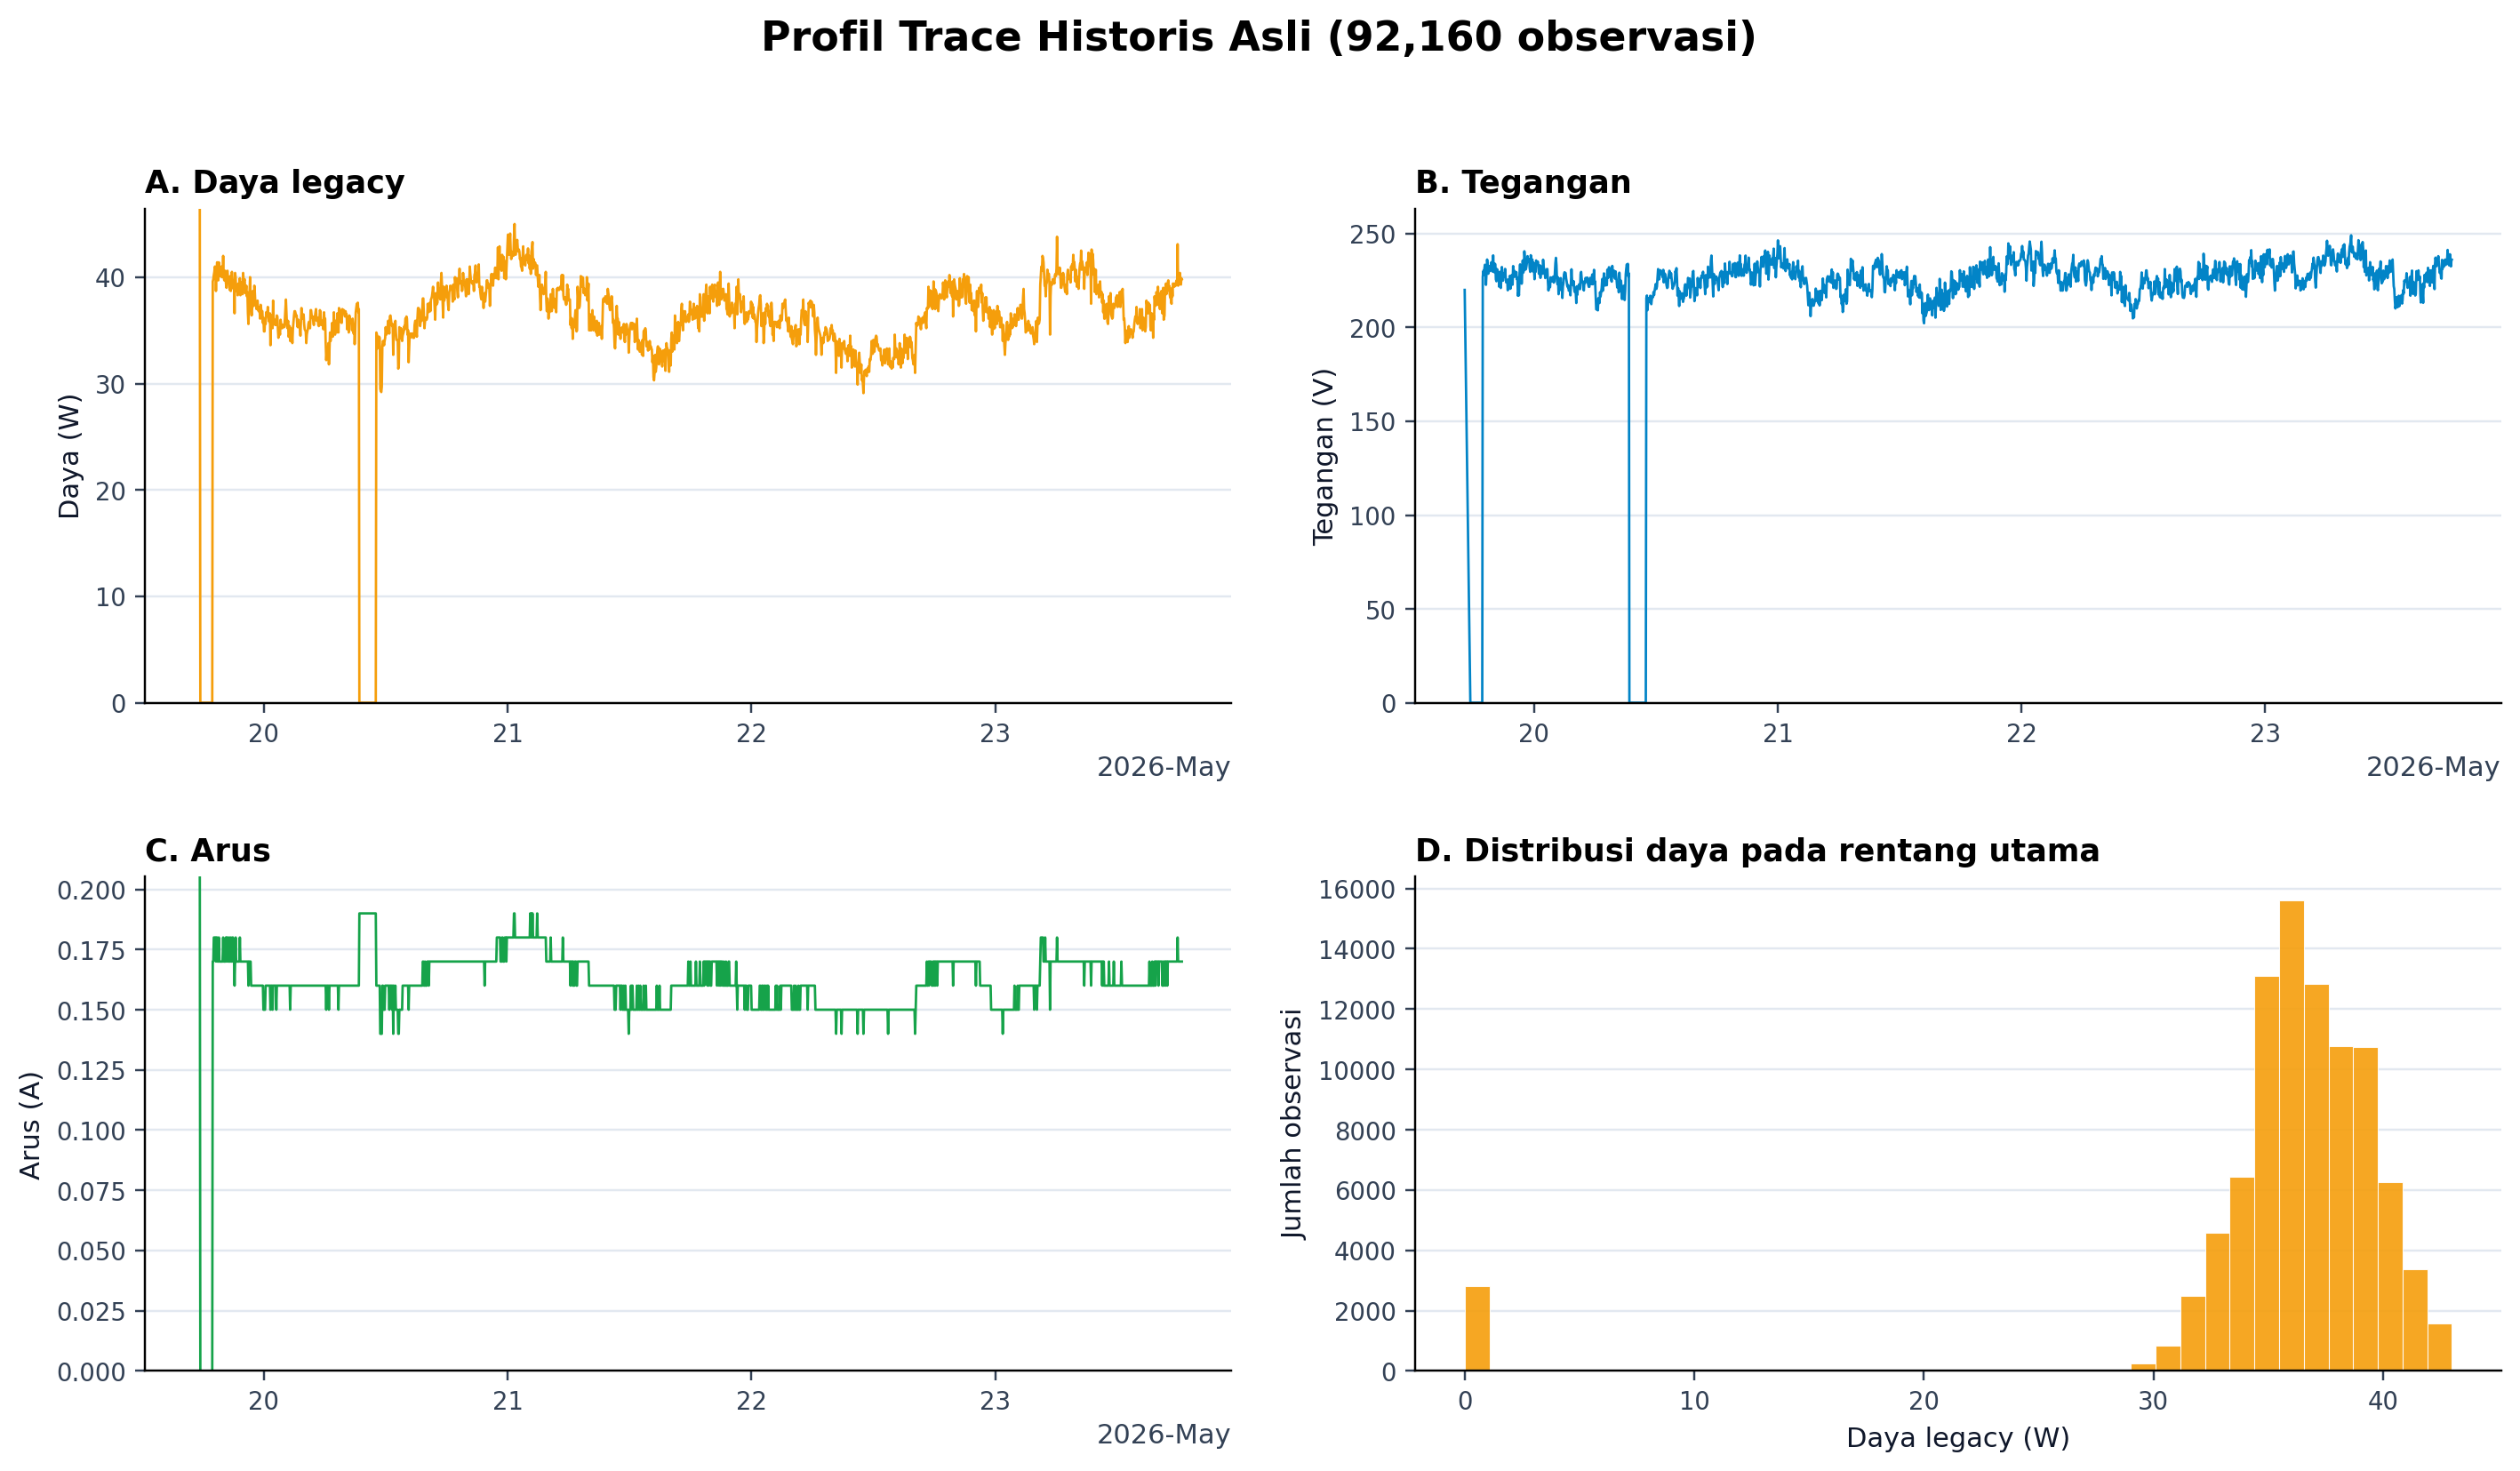

### Provenance replay

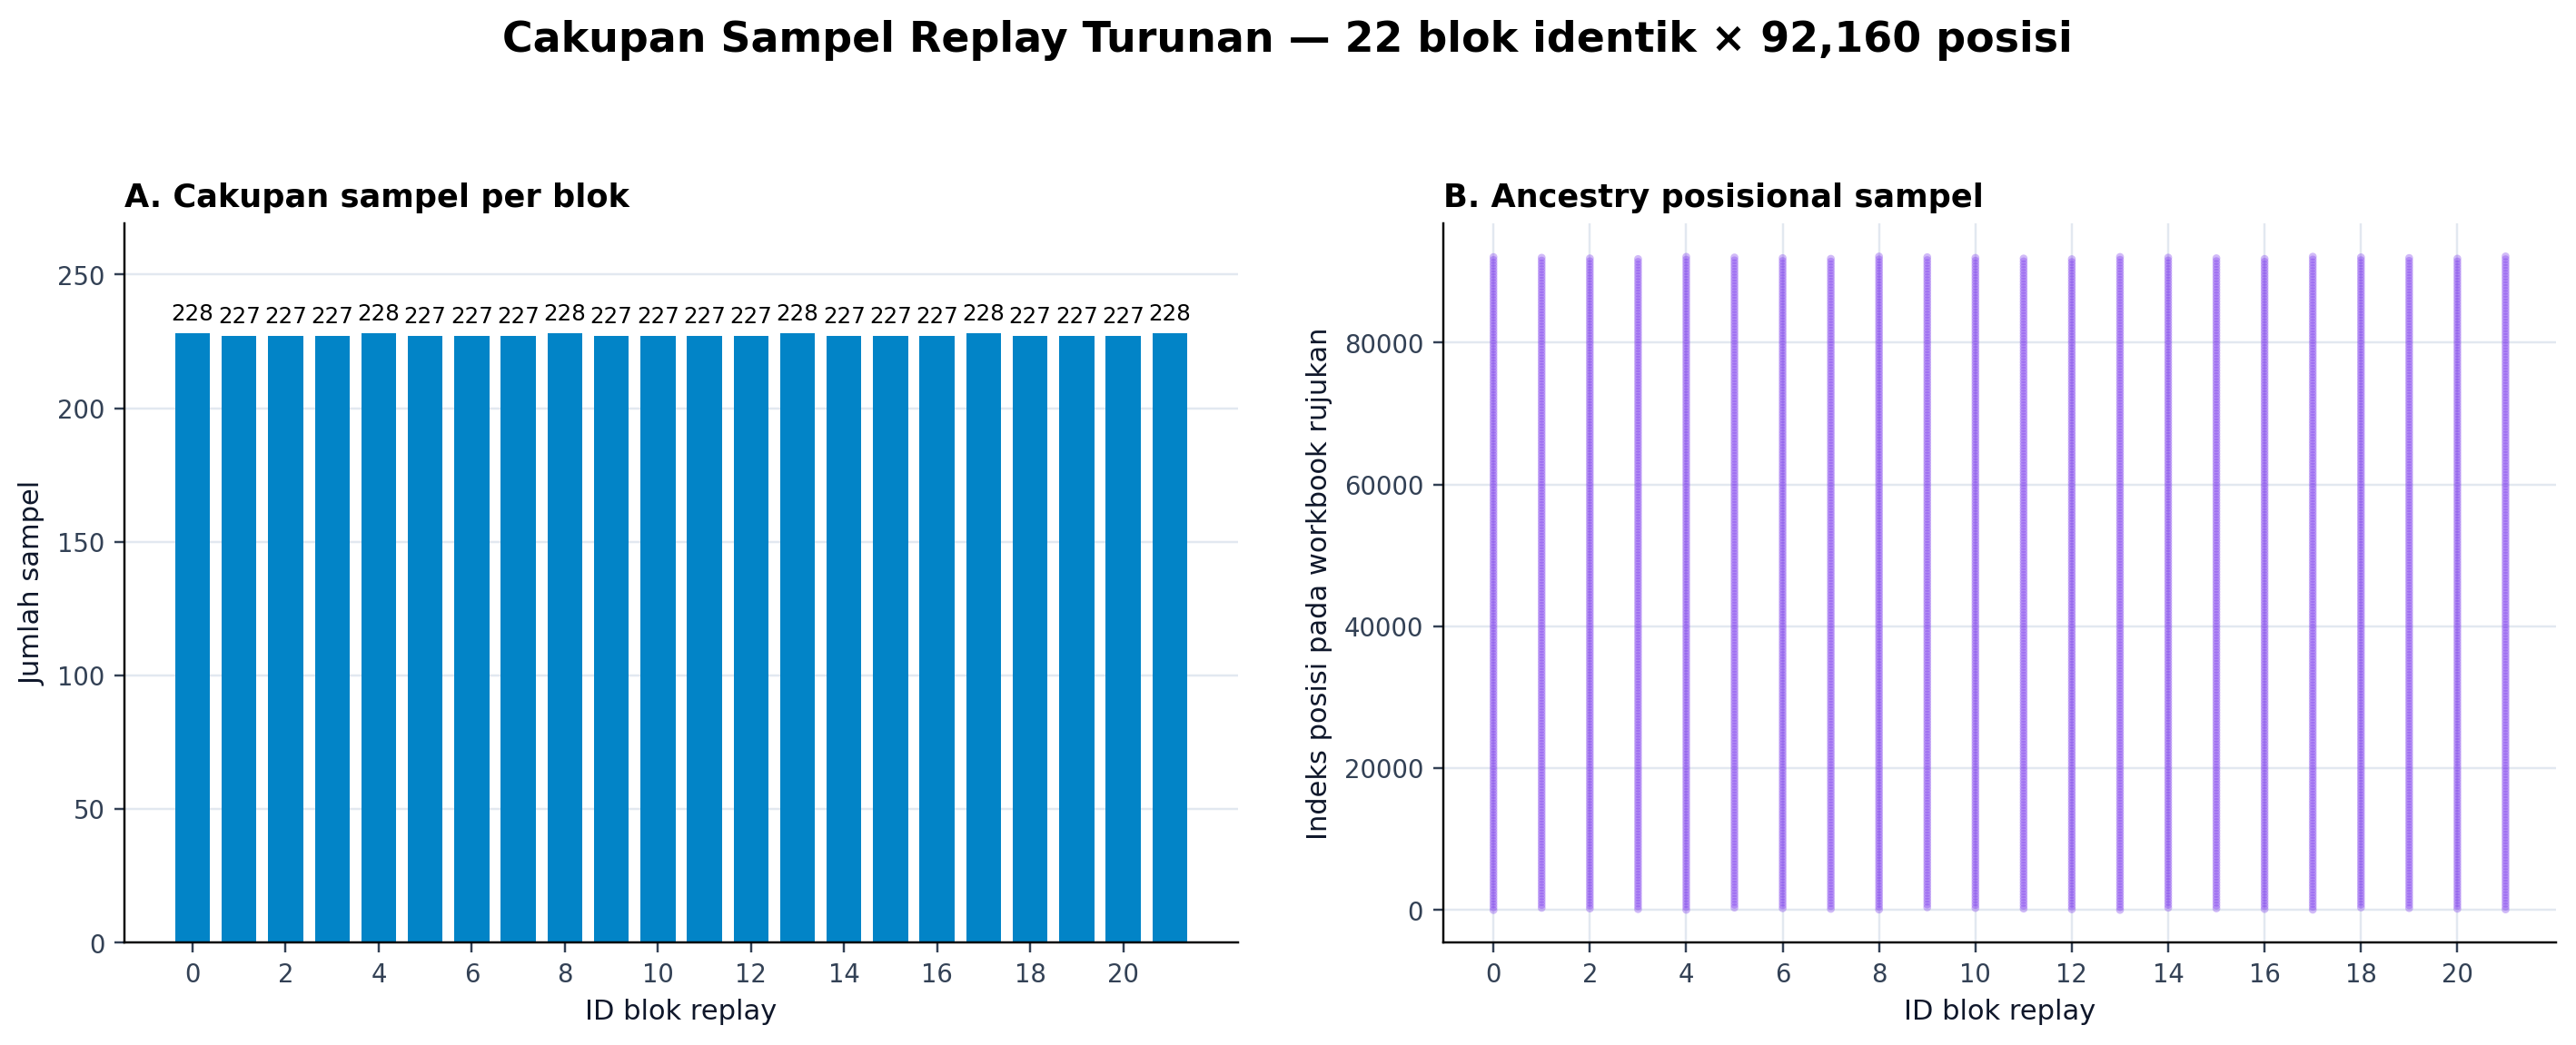

In [13]:
for label in ("Profil trace", "Provenance replay"):
    display(Markdown(f"### {label}"))
    display(Image(filename=str(figure_paths[label])))

### Pemeriksaan monitoring

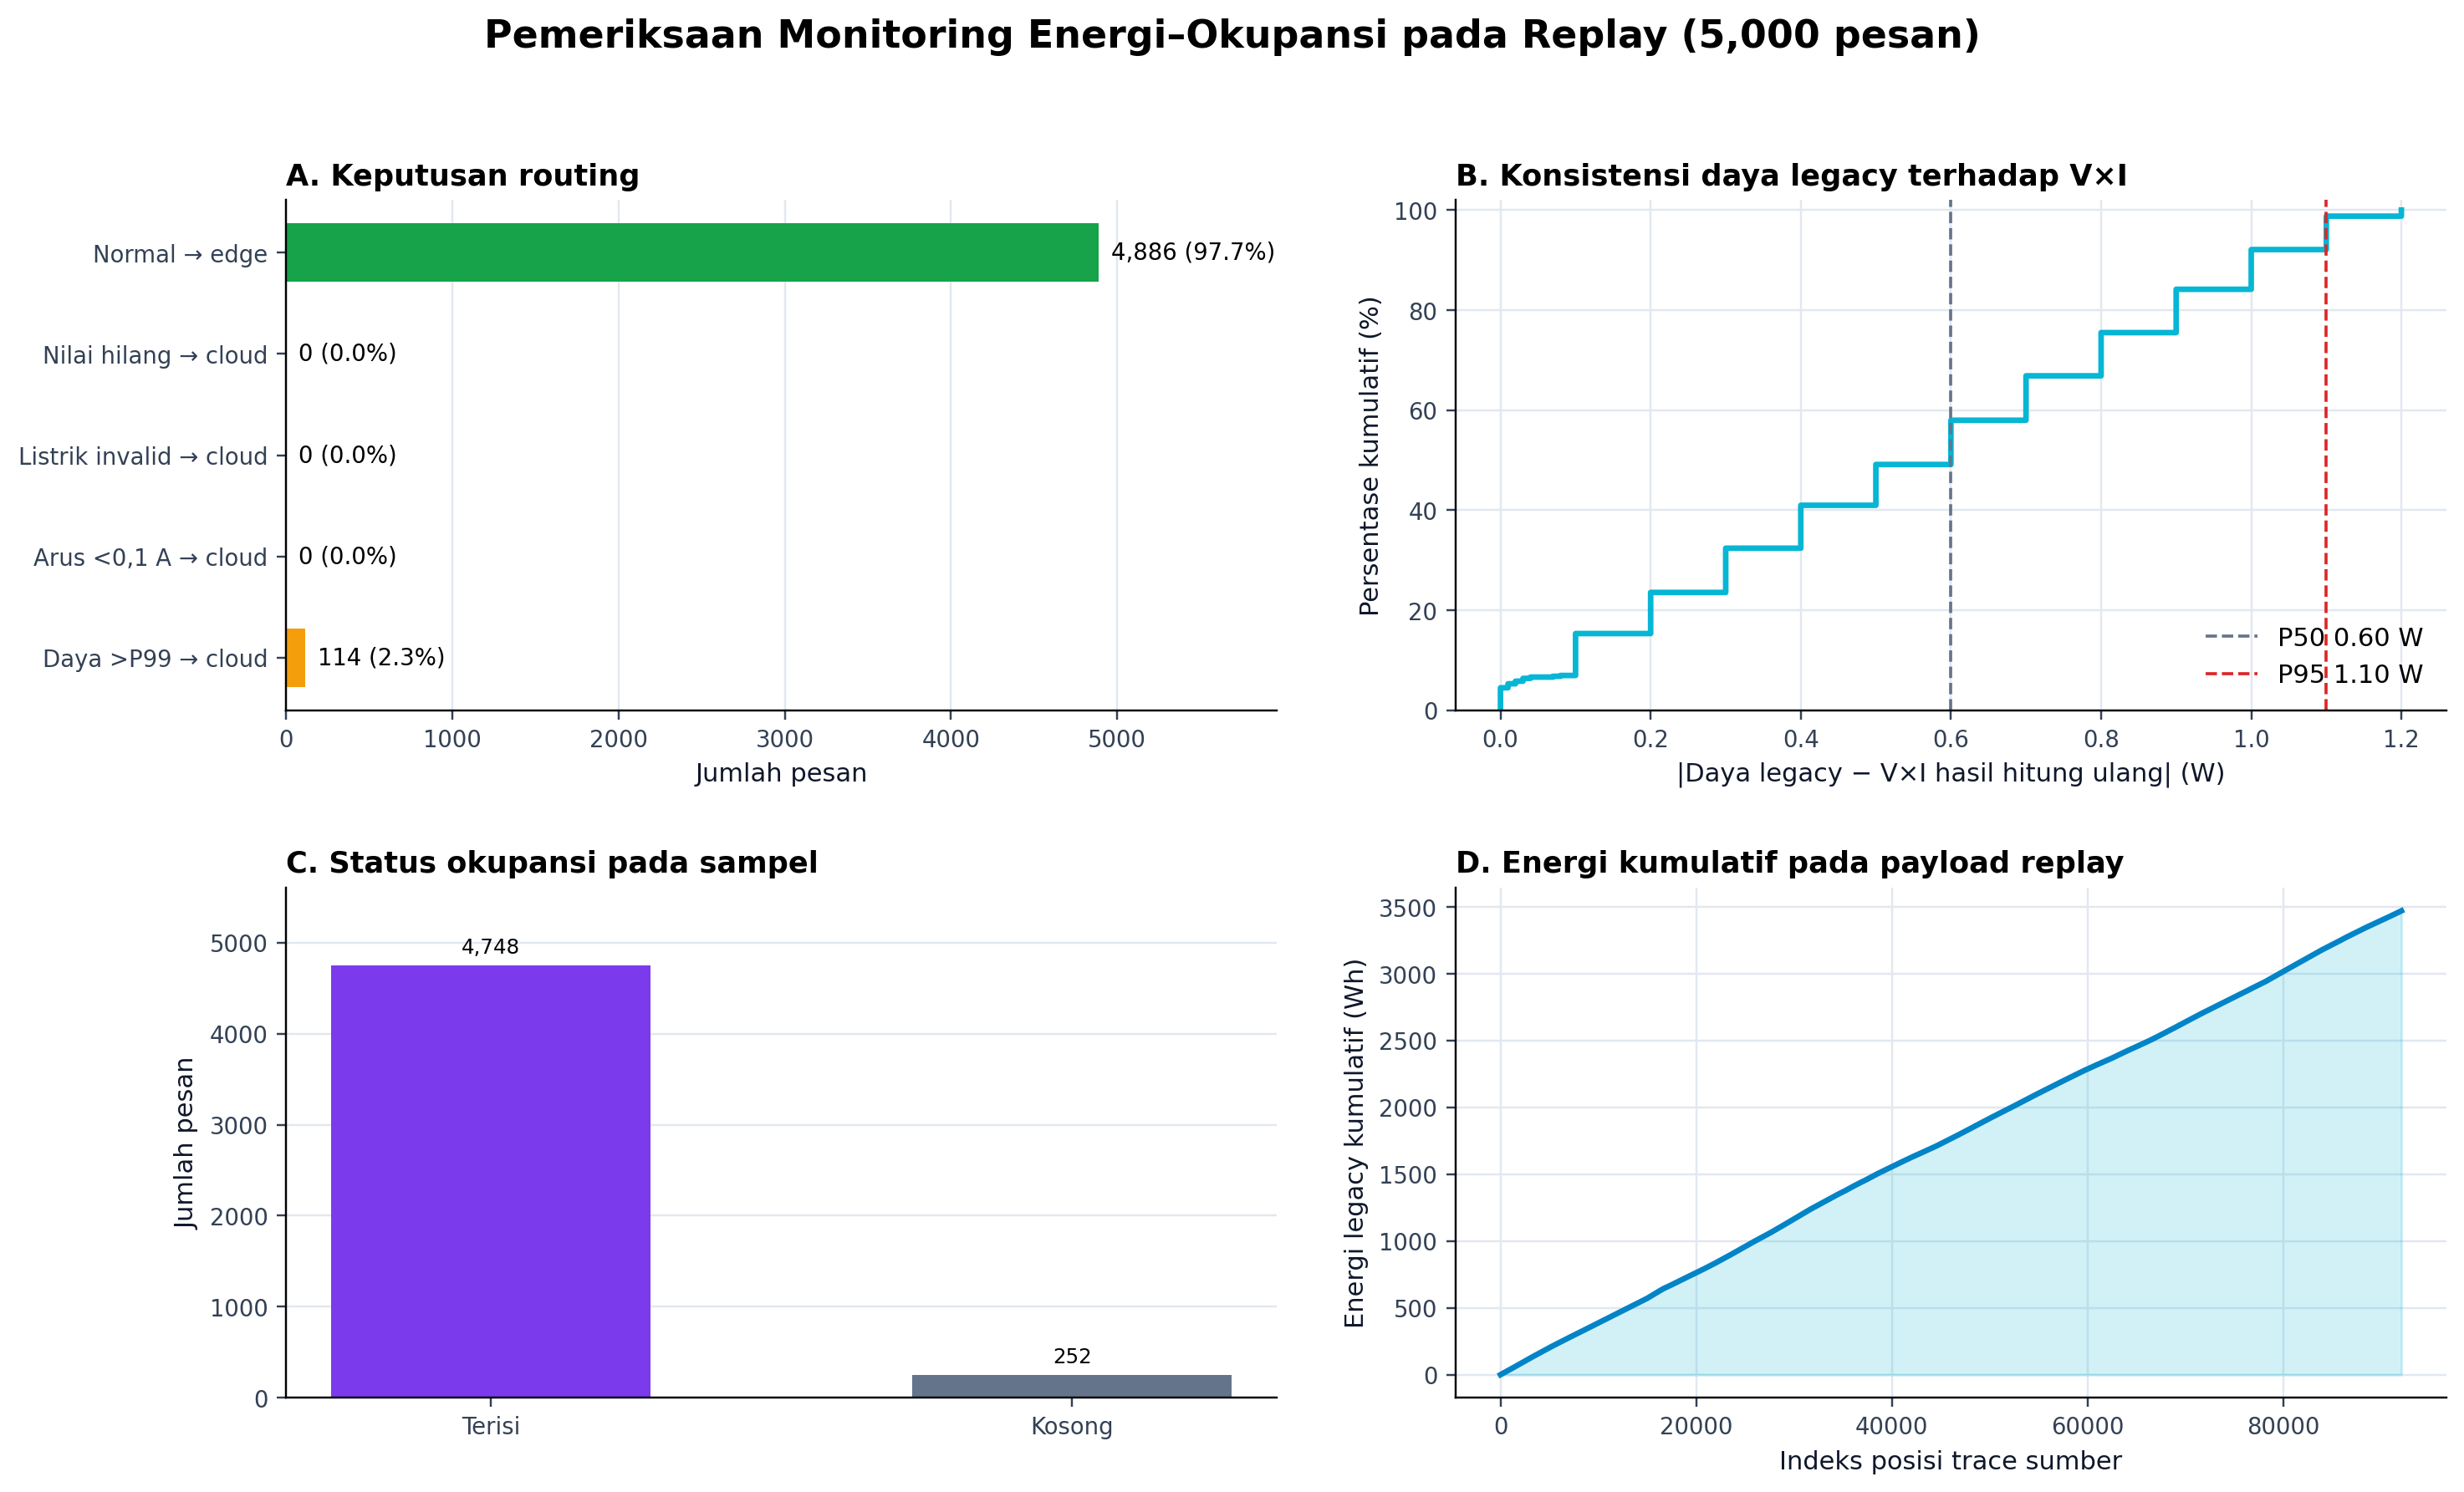

### Karakteristik latensi

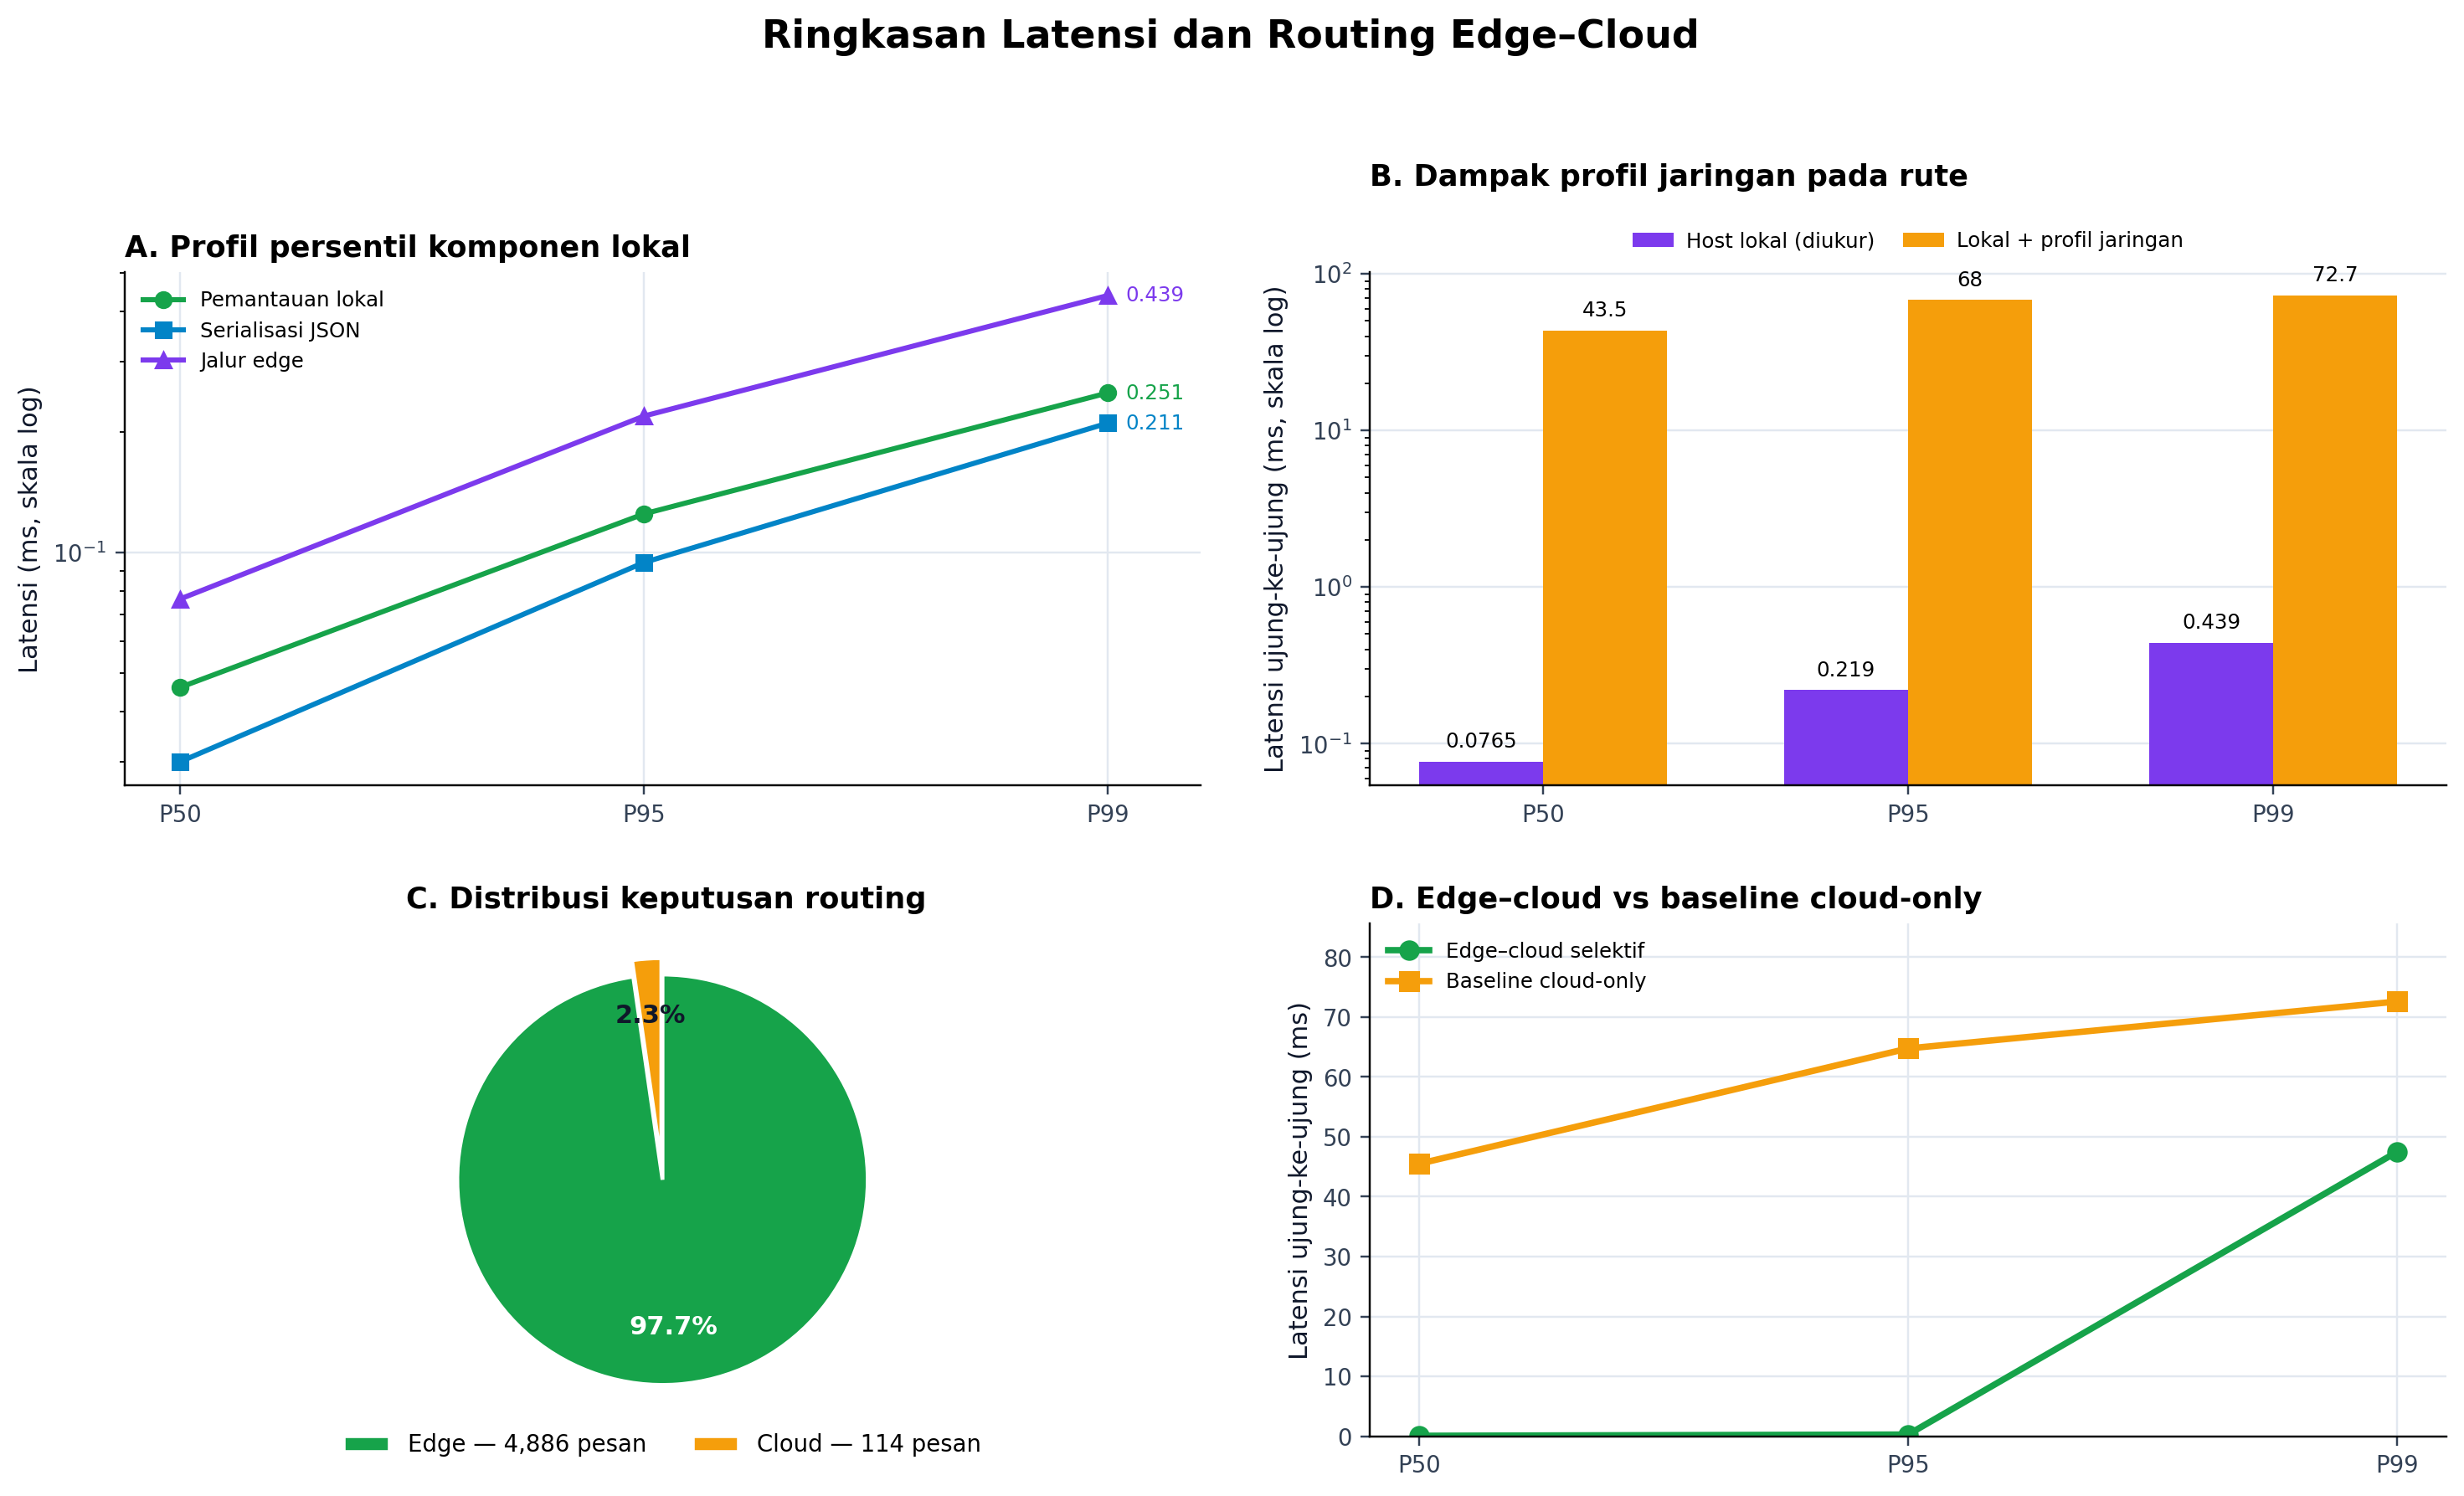

### Digital Twin multiskala

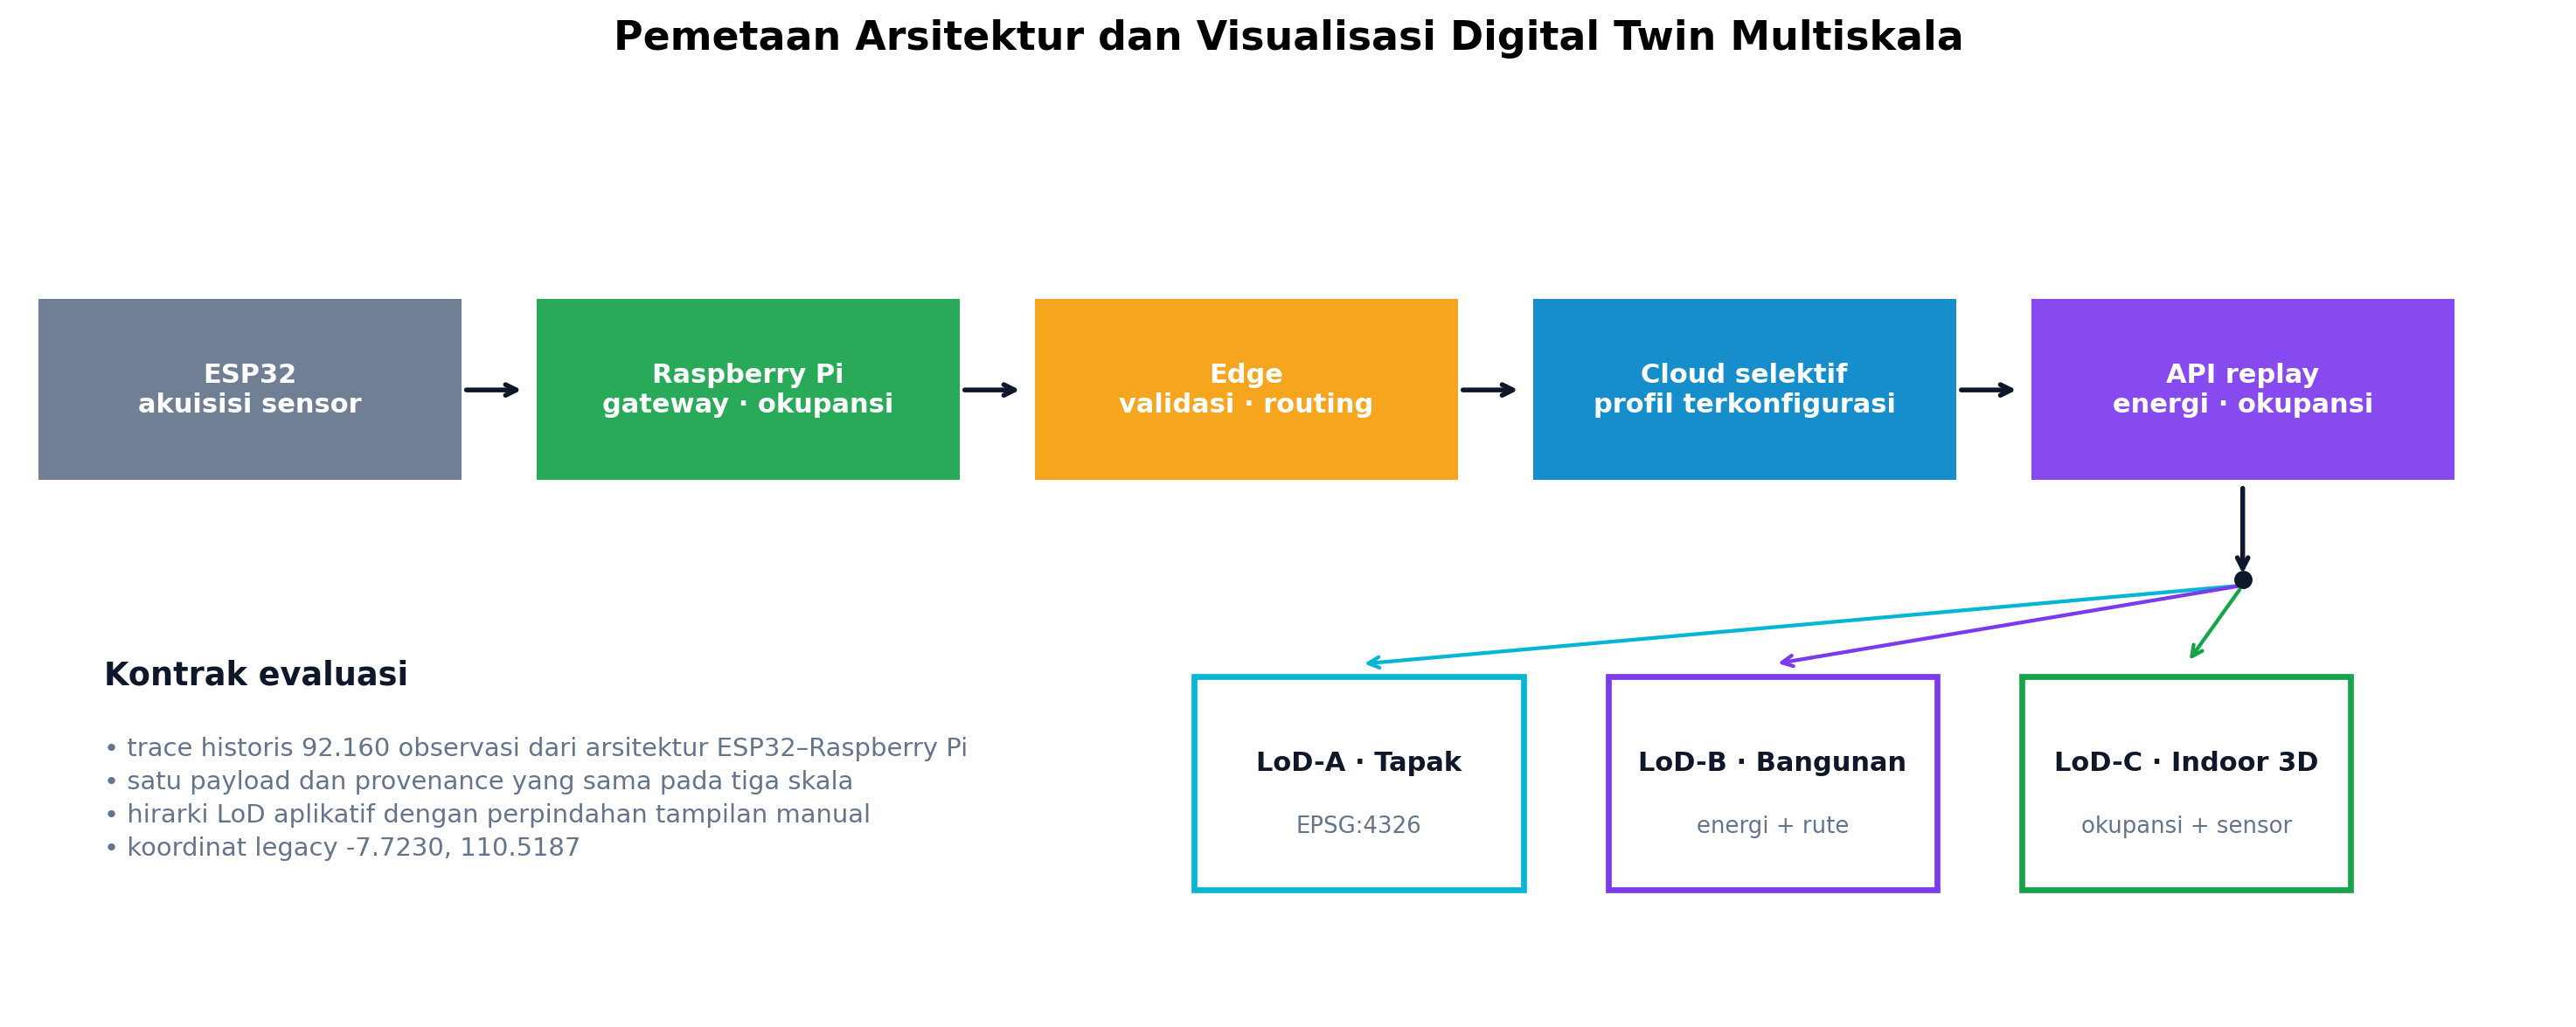

In [14]:
for label in (
    "Pemeriksaan monitoring",
    "Karakteristik latensi",
    "Digital Twin multiskala",
):
    display(Markdown(f"### {label}"))
    display(Image(filename=str(figure_paths[label])))

## 8. Bukti kontrak Digital Twin geospasial–indoor multiskala

Pemeriksaan statis berikut memastikan bahwa konsumen Vue membaca field
`monitoring`, `provenance`, `processing`, dan `digital_twin`,
menggunakan endpoint replay lokal, serta memiliki komponen tapak,
bangunan, dan adegan indoor 3D. Ini adalah bukti konsistensi
integrasi kode—bukan pengukuran performa render, uji pengguna, atau bukti
sinkronisasi dua arah sebuah Digital Twin operasional.

In [15]:
web_root = ROOT / "Digital_Twin" / "dashboard_digitaltwin" / "view_virtual"
telemetry_consumer_path = (
    web_root / "src" / "composables" / "useTelemetry.js"
)
app_config_path = web_root / "src" / "lib" / "appConfig.js"
scene_path = web_root / "public" / "models" / "3d twin" / "scene.gltf"
babylon_path = web_root / "src" / "components" / "DigitalTwin3D_Babylon.vue"
multiscale_path = (
    web_root / "src" / "components" / "MultiscaleDigitalTwin.vue"
)

telemetry_consumer_source = telemetry_consumer_path.read_text(
    encoding="utf-8"
)
app_config_source = app_config_path.read_text(encoding="utf-8")
babylon_source = babylon_path.read_text(encoding="utf-8")
multiscale_source = multiscale_path.read_text(encoding="utf-8")

contract_checks = [
    (
        "Membaca objek monitoring",
        "data.monitoring" in telemetry_consumer_source,
    ),
    (
        "Membaca provenance replay",
        "data.provenance" in telemetry_consumer_source,
    ),
    (
        "Meneruskan klasifikasi lineage",
        "data.provenance.lineage_classification"
        in telemetry_consumer_source,
    ),
    (
        "Membaca keputusan processing/routing",
        "data.processing" in telemetry_consumer_source,
    ),
    (
        "Membaca konteks Digital Twin",
        "data.digital_twin" in telemetry_consumer_source,
    ),
    (
        "Membaca energi dan status okupansi",
        "energy_cumulative_legacy_wh" in telemetry_consumer_source
        and "occupancy_status" in telemetry_consumer_source,
    ),
    (
        "Mengakses /telemetry/latest",
        "/telemetry/latest" in telemetry_consumer_source,
    ),
    (
        "Default API mengarah ke replay lokal",
        "http://127.0.0.1:8000/api" in app_config_source,
    ),
    (
        "Polling near real-time dapat dikonfigurasi",
        "TELEMETRY_POLL_INTERVAL_MS" in app_config_source
        and "TELEMETRY_POLL_INTERVAL_MS"
        in telemetry_consumer_source,
    ),
    (
        "Default polling konsisten 3,5 detik",
        "3500" in app_config_source,
    ),
    ("Komponen Babylon.js tersedia", "@babylonjs" in babylon_source),
    (
        "Tiga skala visual tersedia",
        all(
            view in multiscale_source
            for view in ("geospatial_site", "building", "indoor")
        ),
    ),
    ("Aset scene.gltf tersedia", scene_path.exists()),
    (
        "Tidak membaca field estimasi ML",
        "data.estimate" not in telemetry_consumer_source,
    ),
    (
        "Menolak fallback kontrak gateway lama",
        "data.suhu" not in telemetry_consumer_source
        and "legacy_live_compatibility" not in telemetry_consumer_source,
    ),
]
contract_table = pd.DataFrame(
    contract_checks,
    columns=["Bukti integrasi", "Terpenuhi"],
)
display(contract_table.style.hide(axis="index"))
assert contract_table["Terpenuhi"].all()

contract_audit = {
    "checks": [
        {"check": check, "passed": bool(passed)}
        for check, passed in contract_checks
    ],
    "all_passed": bool(contract_table["Terpenuhi"].all()),
    "scope": (
        "Static contract consistency only; browser rendering, user "
        "experience, bidirectional control, and field synchronization "
        "were not measured."
    ),
    "files": {
        "consumer": str(telemetry_consumer_path.relative_to(ROOT)),
        "configuration": str(app_config_path.relative_to(ROOT)),
        "web_3d_component": str(babylon_path.relative_to(ROOT)),
        "multiscale_component": str(
            multiscale_path.relative_to(ROOT)
        ),
        "scene": str(scene_path.relative_to(ROOT)),
    },
}
write_json(NOTEBOOK_OUTPUT / "frontend_contract_audit.json", contract_audit)

Bukti integrasi,Terpenuhi
Membaca objek monitoring,True
Membaca provenance replay,True
Meneruskan klasifikasi lineage,True
Membaca keputusan processing/routing,True
Membaca konteks Digital Twin,True
Membaca energi dan status okupansi,True
Mengakses /telemetry/latest,True
Default API mengarah ke replay lokal,True
Polling near real-time dapat dikonfigurasi,True
"Default polling konsisten 3,5 detik",True


## 9. Uji regresi kode

Uji Python selalu dijalankan. Uji frontend dijalankan bila
`node_modules/` tersedia; jika belum, jalankan `npm ci` di folder
dashboard lalu ulangi cell ini. Kode pengujian tetap terlihat utuh agar
status “dilewati” tidak disalahartikan sebagai “lulus”.

In [16]:
def run_command(command: list[str], cwd: Path) -> dict:
    started = time.perf_counter()
    completed = subprocess.run(
        command,
        cwd=cwd,
        text=True,
        capture_output=True,
        check=False,
    )
    return {
        "command": " ".join(command),
        "cwd": str(cwd.relative_to(ROOT)) if cwd != ROOT else ".",
        "returncode": completed.returncode,
        "passed": completed.returncode == 0,
        "duration_seconds": time.perf_counter() - started,
        "stdout_tail": completed.stdout[-12000:],
        "stderr_tail": completed.stderr[-12000:],
    }

def detected_test_count(result: dict, pattern: str) -> int | None:
    combined = (
        result["stdout_tail"] + "\n" + result["stderr_tail"]
    )
    without_ansi = re.sub(r"\x1b\[[0-9;]*m", "", combined)
    match = re.search(pattern, without_ansi)
    return int(match.group(1)) if match else None


test_results = [
    run_command(
        [sys.executable, "-m", "unittest", "discover", "-s", "tests", "-v"],
        ROOT,
    )
]

if (web_root / "node_modules").is_dir():
    test_results.append(
        run_command(
            [
                "npm",
                "run",
                "test:run",
                "--",
                "--maxWorkers=1",
                "--no-file-parallelism",
                "--reporter=dot",
            ],
            web_root,
        )
    )
else:
    test_results.append(
        {
            "command": (
                "npm run test:run -- --maxWorkers=1 "
                "--no-file-parallelism --reporter=dot"
            ),
            "cwd": str(web_root.relative_to(ROOT)),
            "returncode": None,
            "passed": None,
            "duration_seconds": 0.0,
            "stdout_tail": "",
            "stderr_tail": "Dilewati: node_modules tidak tersedia; jalankan npm ci.",
        }
    )

test_results[0]["tests_passed"] = detected_test_count(
    test_results[0],
    r"Ran\s+(\d+)\s+tests?",
)
if test_results[1]["passed"] is not None:
    test_results[1]["tests_passed"] = detected_test_count(
        test_results[1],
        r"Tests\s+(\d+)\s+passed",
    )
else:
    test_results[1]["tests_passed"] = None

test_table = pd.DataFrame(
    [
        {
            "Perintah": result["command"],
            "Folder": result["cwd"],
            "Return code": result["returncode"],
            "Status": (
                "LULUS"
                if result["passed"] is True
                else "DILEWATI"
                if result["passed"] is None
                else "GAGAL"
            ),
            "Tes lulus": result["tests_passed"],
            "Durasi (detik)": result["duration_seconds"],
        }
        for result in test_results
    ]
)
display(test_table.style.format({"Durasi (detik)": "{:.2f}"}).hide(axis="index"))
for result in test_results:
    display(Markdown(f"**`{result['command']}`**"))
    if result["stdout_tail"]:
        print(result["stdout_tail"])
    if result["stderr_tail"]:
        print(result["stderr_tail"])
    if not result["stdout_tail"] and not result["stderr_tail"]:
        print("(tanpa output)")

write_json(NOTEBOOK_OUTPUT / "test_results.json", test_results)
assert test_results[0]["passed"] is True
assert test_results[0]["tests_passed"] == 8
assert all(result["passed"] is not False for result in test_results)
if test_results[1]["passed"] is not None:
    assert test_results[1]["tests_passed"] == 35

Perintah,Folder,Return code,Status,Tes lulus,Durasi (detik)
/usr/local/bin/python3 -m unittest discover -s tests -v,.,0,LULUS,8,2.12
npm run test:run -- --maxWorkers=1 --no-file-parallelism --reporter=dot,Digital_Twin/dashboard_digitaltwin/view_virtual,0,LULUS,35,15.59


**`/usr/local/bin/python3 -m unittest discover -s tests -v`**

test_benchmark_measures_monitoring_path_without_model_metrics (test_pipeline.HistoricalReplayPipelineTest.test_benchmark_measures_monitoring_path_without_model_metrics) ... ok
test_energy_integration_exposes_legacy_measurement_scope (test_pipeline.HistoricalReplayPipelineTest.test_energy_integration_exposes_legacy_measurement_scope) ... ok
test_legacy_power_is_checked_not_estimated (test_pipeline.HistoricalReplayPipelineTest.test_legacy_power_is_checked_not_estimated) ... ok
test_lineage_detects_transformation_against_exported_workbook (test_pipeline.HistoricalReplayPipelineTest.test_lineage_detects_transformation_against_exported_workbook) ... ok
test_missing_non_electrical_value_routes_to_cloud (test_pipeline.HistoricalReplayPipelineTest.test_missing_non_electrical_value_routes_to_cloud) ... ok
test_replay_provenance_separates_volume_from_observations (test_pipeline.HistoricalReplayPipelineTest.test_replay_provenance_separates_volume_from_observations) ... ok
test_replay_state_keeps_

**`npm run test:run -- --maxWorkers=1 --no-file-parallelism --reporter=dot`**


> digital-twin-dashboard@1.0.0 test:run
> vitest run --maxWorkers=1 --no-file-parallelism --reporter=dot


 RUN  v4.1.10 /Users/macbookpro/Documents/jurnal_penelitian/Digital_Twin/dashboard_digitaltwin/view_virtual

···································

 Test Files  7 passed (7)
      Tests  35 passed (35)
   Start at  21:37:27
   Duration  13.47s (transform 735ms, setup 0ms, import 2.00s, tests 594ms, environment 8.12s)


(node:86885) Warning: The 'NO_COLOR' env is ignored due to the 'FORCE_COLOR' env being set.
(Use `node --trace-warnings ...` to show where the warning was created)
(node:86922) Warning: The 'NO_COLOR' env is ignored due to the 'FORCE_COLOR' env being set.
(Use `node --trace-warnings ...` to show where the warning was created)
(node:86951) Warning: The 'NO_COLOR' env is ignored due to the 'FORCE_COLOR' env being set.
(Use `node --trace-warnings ...` to show where the warning was created)
(node:86973) Warning: The 'NO_COLOR' env is ignored due to the 'FORCE_COLOR' env 

## 10. Matriks kesesuaian judul

Status “sebagian” berarti implementasi atau bukti awal tersedia, tetapi
klaim belum boleh diperluas melampaui kondisi eksperimen.

In [17]:
lineage_classification = replay_audit.get("lineage", {}).get(
    "classification",
    replay_audit["provenance"].get("lineage_classification", "belum tersedia"),
)
evidence_matrix = pd.DataFrame(
    [
        {
            "Komponen judul": "Arsitektur edge–cloud",
            "Status": "Sebagian",
            "Bukti": "Routing lokal terukur dan rute cloud diemulasi dengan konfigurasi tetap.",
            "Yang belum": "Perangkat edge dan public cloud nyata belum diukur.",
        },
        {
            "Komponen judul": "Monitoring energi",
            "Status": "Didukung dalam batas data",
            "Bukti": "Trace XLSX dari arsitektur ESP32–Raspberry Pi, integrasi V×I, dan perbandingan perangkat–meter PLN yang dilaporkan peneliti.",
            "Yang belum": "Tidak ada faktor daya atau pasangan pembacaan meter PLN per interval untuk menghitung galat secara reproduktif.",
        },
        {
            "Komponen judul": "Monitoring okupansi",
            "Status": "Didukung dalam batas data",
            "Bukti": "people_count dan occupied/unoccupied dibawa pada kontrak API.",
            "Yang belum": "Akurasi sensor okupansi lama tidak divalidasi ulang.",
        },
        {
            "Komponen judul": "Near real-time",
            "Status": "Sebagian",
            "Bukti": (
                f"Deadline {deadline_ms:,.0f} ms; tidak ada miss pada "
                f"{mixed['delivered_count']:,} pesan terkirim dan "
                f"{mixed['dropped_count']:,} pesan tercatat drop."
            ),
            "Yang belum": "Render browser, broker, dan jaringan lapangan tidak diukur.",
        },
        {
            "Komponen judul": "Bangunan cerdas",
            "Status": "Terbatas",
            "Bukti": "Trace telemetry bangunan dan jumlah orang dari arsitektur ESP32–Raspberry Pi dengan satu ID gateway agregasi.",
            "Yang belum": "Generalisasi lintas ruang, perangkat, musim, dan gedung.",
        },
        {
            "Komponen judul": "Visual geospasial–indoor multiskala",
            "Status": "Sebagian",
            "Bukti": "LoD-A tapak EPSG:4326, LoD-B bangunan, LoD-C Vue/Babylon.js, dan scene.gltf terhubung ke payload yang sama.",
            "Yang belum": "Koordinat survei, kepatuhan LoD geometrik standar, transisi otomatis, render latency, dan studi pengguna.",
        },
        {
            "Komponen judul": "Replay data historis",
            "Status": "Didukung",
            "Bukti": f"Audit penuh {expected_rows:,} baris; lineage: {lineage_classification}.",
            "Yang belum": "Kode pembentuk transformasi lama tidak tersedia bila dinyatakan demikian oleh audit lineage.",
        },
    ]
)
display(evidence_matrix.style.hide(axis="index"))

Komponen judul,Status,Bukti,Yang belum
Arsitektur edge–cloud,Sebagian,Routing lokal terukur dan rute cloud diemulasi dengan konfigurasi tetap.,Perangkat edge dan public cloud nyata belum diukur.
Monitoring energi,Didukung dalam batas data,"Trace XLSX dari arsitektur ESP32–Raspberry Pi, integrasi V×I, dan perbandingan perangkat–meter PLN yang dilaporkan peneliti.",Tidak ada faktor daya atau pasangan pembacaan meter PLN per interval untuk menghitung galat secara reproduktif.
Monitoring okupansi,Didukung dalam batas data,people_count dan occupied/unoccupied dibawa pada kontrak API.,Akurasi sensor okupansi lama tidak divalidasi ulang.
Near real-time,Sebagian,"Deadline 3,500 ms; tidak ada miss pada 5,000 pesan terkirim dan 0 pesan tercatat drop.","Render browser, broker, dan jaringan lapangan tidak diukur."
Bangunan cerdas,Terbatas,Trace telemetry bangunan dan jumlah orang dari arsitektur ESP32–Raspberry Pi dengan satu ID gateway agregasi.,"Generalisasi lintas ruang, perangkat, musim, dan gedung."
Visual geospasial–indoor multiskala,Sebagian,"LoD-A tapak EPSG:4326, LoD-B bangunan, LoD-C Vue/Babylon.js, dan scene.gltf terhubung ke payload yang sama.","Koordinat survei, kepatuhan LoD geometrik standar, transisi otomatis, render latency, dan studi pengguna."
Replay data historis,Didukung,"Audit penuh 2,027,520 baris; lineage: deterministic_replay_of_transformed_historical_trace.",Kode pembentuk transformasi lama tidak tersedia bila dinyatakan demikian oleh audit lineage.


## 11. Ancaman validitas dan batas interpretasi

1. **Validitas data:** trace asli berasal dari sensor fisik pada satu
   `device_id` dan sekitar empat hari; cakupan tidak mewakili variasi
   antargedung atau musiman.
2. **Lineage:** blok replay adalah pengulangan deterministik dari blok
   historis yang telah mengalami transformasi/imputasi. Selisih
   per-kolom dicatat di audit; 22 blok tidak independen.
3. **Definisi daya:** daya firmware lama adalah proxy V×I berlabel watt,
   tanpa pengukuran faktor daya. Hasil tidak boleh disebut validasi daya
   aktif.
4. **Definisi energi:** integral Wh diturunkan dari V×I. Perbandingan
   dengan meter kWh PLN dilaporkan peneliti, tetapi angka awal–akhir
   per interval tidak tersimpan sehingga galat tidak dapat dihitung
   ulang; gap di atas batas dikeluarkan.
5. **Validitas performa:** waktu lokal bergantung mesin notebook.
   Jaringan cloud merupakan emulasi terkonfigurasi, sedangkan broker,
   perangkat edge, public cloud, dan latensi render belum diukur.
6. **Digital Twin:** UI tiga skala dan kontrak telemetry membuktikan
   integrasi prototipe pemantauan. Belum ada validasi sinkronisasi
   lapangan atau kontrol dua arah.
7. **Geospasial dan LoD:** LoD-A tapak, LoD-B bangunan, dan LoD-C
   indoor merupakan hirarki tingkat detail aplikatif proyek dengan
   perpindahan manual. Koordinat berasal dari implementasi legacy dan
   kepatuhan LoD geometrik CityGML/IndoorGML/IFC/3D Tiles belum diuji.
8. **Tidak ada model estimasi:** replay dipakai untuk workload
   arsitektur. Tidak ada akurasi, presisi, R², MAE, atau klaim “90%”.

## 12. Manifest run dan hash artefak

Manifest mencatat versi runtime, commit Git, hash input, hash konfigurasi
dan hasil utama, serta durasi tahap. Ini memungkinkan pemeriksa
membedakan perubahan data, metode, dan lingkungan eksekusi.

In [18]:
def git_output(*arguments: str) -> str:
    completed = subprocess.run(
        ["git", *arguments],
        cwd=ROOT,
        text=True,
        capture_output=True,
        check=False,
    )
    return completed.stdout.strip() if completed.returncode == 0 else "tidak tersedia"


artifact_paths = {
    "config": CONFIG_PATH,
    "schema": SCHEMA_PATH,
    "notebook_replay_sample": replay_sample_path,
    "trace_audit": NOTEBOOK_OUTPUT / "trace_audit.json",
    "replay_audit": NOTEBOOK_OUTPUT / "historical_replay_audit.json",
    "benchmark": NOTEBOOK_OUTPUT / "benchmark_metrics.json",
    "schema_validation": NOTEBOOK_OUTPUT / "schema_validation.json",
    "api_smoke": NOTEBOOK_OUTPUT / "api_smoke_test.json",
    "frontend_contract": NOTEBOOK_OUTPUT / "frontend_contract_audit.json",
    "test_results": NOTEBOOK_OUTPUT / "test_results.json",
    **{f"figure_{index:02d}": path for index, path in enumerate(figure_paths.values(), start=1)},
}

manifest = {
    "generated_at_utc": datetime.now(timezone.utc).isoformat(),
    "project_title": config["project"]["title"],
    "scope": {
        "reference_rows": source["rows"],
        "available_rows_scanned": replay_audit["source"]["rows"],
        "messages_benchmarked": len(replay_sample),
        "available_rows_are_not_messages_benchmarked": True,
        "schema_validated_payloads": schema_validation["payloads_checked"],
        "model_training_used": False,
    },
    "delivery_accounting": {
        "attempted_count": mixed["attempted_count"],
        "delivered_count": mixed["delivered_count"],
        "dropped_count": mixed["dropped_count"],
        "deadline_miss_count_among_delivered": mixed[
            "deadline_miss_count"
        ],
    },
    "api_contract": {
        "replay_clock": api_smoke["health"]["replay_clock"],
        "lineage_classification": api_smoke["health"][
            "lineage_classification"
        ],
        "request_driven_history_count": api_smoke[
            "request_driven_history_count"
        ],
    },
    "tests": {
        "python_passed": test_results[0]["tests_passed"],
        "frontend_passed": test_results[1]["tests_passed"],
    },
    "input_sha256": {
        "reference_workbook": trace_audit["source"]["sha256"],
        "historical_replay_csv": replay_audit["source"]["sha256"],
    },
    "artifact_sha256": {
        label: sha256_file(path)
        for label, path in artifact_paths.items()
        if path.exists()
    },
    "runtime": {
        "platform": platform.platform(),
        "python": sys.version.split()[0],
        "numpy": np.__version__,
        "pandas": pd.__version__,
        "openpyxl": package_version("openpyxl"),
        "matplotlib": package_version("matplotlib"),
        "jsonschema": package_version("jsonschema"),
        "nbformat": package_version("nbformat"),
    },
    "git": {
        "commit": git_output("rev-parse", "HEAD"),
        "branch": git_output("branch", "--show-current"),
        "worktree_dirty": bool(git_output("status", "--porcelain")),
    },
    "durations_seconds": {
        "trace_audit": trace_seconds,
        "replay_full_scan_and_sampling": replay_seconds,
        "benchmark": benchmark_seconds,
        "schema_validation": validation_seconds,
    },
}
write_json(NOTEBOOK_OUTPUT / "run_manifest.json", manifest)

display(
    pd.DataFrame(
        [
            ["Workbook asli", f"{source['rows']:,} baris", trace_audit["source"]["sha256"]],
            ["available_rows_scanned", f"{replay_audit['source']['rows']:,} baris", replay_audit["source"]["sha256"]],
            ["messages_benchmarked", f"{len(replay_sample):,} pesan", "lihat benchmark_metrics.json"],
            [
                "Delivery",
                f"{mixed['delivered_count']:,}/{mixed['attempted_count']:,} terkirim",
                f"{mixed['dropped_count']:,} drop",
            ],
            ["Schema", f"{schema_validation['payloads_checked']:,} payload", f"{schema_validation['error_count']} error"],
        ],
        columns=["Lingkup", "Jumlah", "Identitas / hasil"],
    ).style.hide(axis="index")
)
print(f"Manifest tersimpan: {NOTEBOOK_OUTPUT / 'run_manifest.json'}")

Lingkup,Jumlah,Identitas / hasil
Workbook asli,"92,160 baris",dd8b5028eda7bca0265da4ada881e1ed1f1ec84afb6b6f0a33cd82f9984f4d29
available_rows_scanned,"2,027,520 baris",ca7831a188a191edbf82a673fac90dbb875b5095986ed07699c02530f2a02a0e
messages_benchmarked,"5,000 pesan",lihat benchmark_metrics.json
Delivery,"5,000/5,000 terkirim",0 drop
Schema,"5,000 payload",0 error


Manifest tersimpan: /Users/macbookpro/Documents/jurnal_penelitian/outputs/notebook/run_manifest.json


## Kesimpulan notebook

Run dinyatakan berhasil bila seluruh assertion di atas selesai:

- workbook asli teridentifikasi dan diaudit;
- seluruh 2.027.520 baris CSV dipindai, tetapi hanya 5.000 pesan
  dibenchmark;
- lineage transformasi dan pengulangan blok dilaporkan eksplisit;
- benchmark routing/latensi menggunakan fungsi produksi yang sama;
- attempted/delivered/dropped dicatat terpisah dan deadline dihitung
  hanya pada pesan yang terkirim;
- semua 5.000 payload memenuhi schema;
- endpoint replay API, lineage health, dan riwayat *request-driven*
  lolos smoke test;
- energi-proksi dan okupansi dipetakan ke kontrak API;
- baseline cloud-only dibandingkan dengan edge–cloud pada kondisi sama;
- kontrak frontend geospasial–bangunan–indoor konsisten;
- uji Python lulus dan uji frontend tidak gagal (atau dinyatakan
  dilewati bila dependensi belum dipasang).

Bukti saat ini cukup untuk **evaluasi prototipe arsitektur berbasis
replay historis dengan trace sensor lapangan**. Data ini belum cukup
untuk menghitung galat kalibrasi terhadap meter PLN secara reproduktif,
performa public cloud, Digital Twin dua arah, akurasi geospasial survei,
atau generalisasi lintas bangunan.